# Pong (Atari) — DQN с Experience Replay и CNN

**Обучение DQN для задачи `Pong-v0`.**  
В этом ноутбуке мы строим и обучаем агента DQN с **experience replay**, **свёрточной сетью** для обработки кадров и **предобработкой изображений** (grayscale → resize до 84×84 → нормализация). Цель — добиться **стабильной сходимости** и продемонстрировать метрики/графики, пригодные для портфолио.

**Tech stack:** PyTorch · Gymnasium (Atari) · ALE · TensorBoard  
**RL-приёмы:** ε-greedy, target network, soft-update τ, mini-batches, replay buffer

## Цели
1. Инициализировать среду `Pong-v0` и реализовать предобработку кадров (84×84, оттенки серого, нормализация, стек 4 кадров).
2. Построить CNN-аппроксиматор Q-функции (архитектура в духе Nature DQN).
3. Реализовать DQN-обучение с мини-батчами из **experience replay** и target-сетью.
4. Оценить качество: **средняя награда за эпизод**, график сходимости (reward vs. frames/episodes).
5. Провести короткий гиперпараметрический анализ: влияние размера буфера, ε-расписания, шага обучения.

## Краткая идея алгоритма
На каждом шаге агент действует по ε-greedy политике, складывает переходы в **replay buffer**, и периодически обновляет весa онлайн-сети, минимизируя MSE между текущей Q-оценкой и целевым значением:
\[
y = r + \gamma \cdot (1 - \text{done}) \cdot \max_{a'} Q_{\text{target}}(s', a')
\]
Target-сеть плавно приближается к онлайн-сети через **soft-update** с коэффициентом \(\tau\).

## Что в ноутбуке
- **Подготовка данных:** создание `Pong-v0`, обёртки/преобразования кадров, sanity-check форматов.
- **Модель:** CNN (3× Conv + FC), вывод числа параметров, тест прямого прохода.
- **Буфер:** uniform **experience replay** с выборкой мини-батчей.
- **Обучение:** цикл по кадрам/эпизодам с логированием в TensorBoard/CSV.
- **Оценка:** средняя награда за N эпизодов, запись короткого mp4.
- **Графики:** reward per episode, moving average(100), loss, ε-schedule.
- **HParams-анализ:** несколько коротких прогонов с разными `buffer_size`, `epsilon_decay`, `lr`.

## Метрики и артефакты
- `avg_reward` (по эпизодам и скользящему окну 100)
- `loss`, распределение Q-значений (по желанию)
- Логи TensorBoard: `artifacts_pong/tensorboard/`
- Чекпоинты: `artifacts_pong/checkpoints/`
- Видео: `artifacts_pong/videos/`
- CSV с метриками: `artifacts_pong/metrics_pong.csv`
- Графики PNG: `artifacts_pong/plots/`

## Baseline

In [1]:
# Core
import math
import os
import random
import subprocess
import sys
import time
from pathlib import Path
from collections import deque
from typing import Tuple, Optional, List, Dict

# Numerics & plotting
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.tensorboard import SummaryWriter
from torch.cuda.amp import autocast, GradScaler 

# Gym / Atari 
import ale_py
import AutoROM
import gymnasium as gym

# Image / video utils
import cv2 
import imageio.v2 as imageio 

# Config
import yaml

# Progress / warnings
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}, CUDA: {torch.cuda.is_available()}, torch={torch.__version__}, gym={gym.__version__}")

Device: cuda, CUDA: True, torch=2.5.1, gym=0.29.1


In [3]:
# === Paths & folders (Pong) ===
from datetime import datetime

# 1) Корень проекта (можно переопределить переменной окружения RL_PROJECT_ROOT)
PROJECT_ROOT = Path(
    os.getenv("RL_PROJECT_ROOT", r"D:\ML\LS\Deep_learning\Reinforcement_learning\project")
).resolve()

CWD = Path.cwd().resolve()
print("CWD         =", CWD)
print("PROJECT_ROOT=", PROJECT_ROOT)

# 2) Конфиг и витрина артефактов именно для PONG
CONFIG_BASE    = PROJECT_ROOT / "configs" / "pong.yaml"

ARTIFACTS      = PROJECT_ROOT / "artifacts_pong"
TB_DIR         = ARTIFACTS / "tensorboard"
CHECKPOINTS_DIR= ARTIFACTS / "checkpoints"
PLOTS_DIR      = ARTIFACTS / "plots"
VIDEOS_DIR     = ARTIFACTS / "videos"
METRICS_CSV    = ARTIFACTS / "metrics_pong.csv"

for p in [ARTIFACTS, TB_DIR, CHECKPOINTS_DIR, PLOTS_DIR, VIDEOS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version)
print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
print("Gymnasium:", gym.__version__)
print("Config ->", CONFIG_BASE)
print("TensorBoard logs ->", TB_DIR)
print("Checkpoints ->", CHECKPOINTS_DIR)
print("Plots ->", PLOTS_DIR)
print("Videos ->", VIDEOS_DIR)
print("Metrics CSV ->", METRICS_CSV)

CWD         = D:\ML\LS\Deep_learning\Reinforcement_learning\project\notebooks
PROJECT_ROOT= D:\ML\LS\Deep_learning\Reinforcement_learning\project
Python: 3.10.14 | packaged by conda-forge | (main, Mar 20 2024, 12:40:08) [MSC v.1938 64 bit (AMD64)]
Torch: 2.5.1 | CUDA available: True
Gymnasium: 0.29.1
Config -> D:\ML\LS\Deep_learning\Reinforcement_learning\project\configs\pong.yaml
TensorBoard logs -> D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard
Checkpoints -> D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints
Plots -> D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\plots
Videos -> D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\videos
Metrics CSV -> D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\metrics_pong.csv


In [4]:
# === Utils for config, TB, training launcher ===

# YAML helpers
def load_yaml(path: Path):
    with open(path, 'r', encoding='utf-8') as f:
        return yaml.safe_load(f) or {}

def deep_update(d, u):
    """Recursively update dict d with dict u (u has priority)."""
    for k, v in (u or {}).items():
        if isinstance(v, dict) and isinstance(d.get(k), dict):
            d[k] = deep_update(d[k], v)
        else:
            d[k] = v
    return d

def save_yaml(d, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        yaml.safe_dump(d, f, sort_keys=False, allow_unicode=True)
    return path

def enforce_pong_paths(cfg: dict) -> dict:
    """Жёстко проставляет log.* в artifacts_pong/*, игнорируя, что в YAML."""
    cfg = dict(cfg)  # shallow copy
    log = dict(cfg.get("log") or {})
    log["out_dir"]   = str(TB_DIR)
    log["save_dir"]  = str(CHECKPOINTS_DIR)
    log["plots_dir"] = str(PLOTS_DIR)
    log["metrics_csv"]= str(METRICS_CSV)
    cfg["log"] = log
    # оставим обратную совместимость со старой схемой
    logging_b = dict(cfg.get("logging") or {})
    logging_b["log_dir"] = str(TB_DIR)
    cfg["logging"] = logging_b
    return cfg

# Training launcher
def run_training_with_config(tmp_cfg_path: Path,
                             module_name: str = "train.train_pong",
                             extra_args=None,
                             cwd: Path = PROJECT_ROOT):
    """
    Запускает тренировочный модуль (по умолчанию train.train_pong) в контексте корня проекта.
    Пример: run_training_with_config(path, extra_args=["--smoke"])
    """
    cmd = [sys.executable, "-m", module_name, "--config", str(tmp_cfg_path)]
    if extra_args:
        cmd += list(map(str, extra_args))
    print("RUN (cwd=PROJECT_ROOT):", " ".join(map(str, cmd)))
    return subprocess.run(cmd, capture_output=False, cwd=cwd).returncode

# TensorBoard helpers
def latest_tb_run(tb_dir=TB_DIR):
    """
    Возвращает директорию последнего TB-рана (по времени модификации events.*)
    """
    ev = sorted(Path(tb_dir).rglob("events.*"), key=lambda p: p.stat().st_mtime, reverse=True)
    return ev[0].parent if ev else None

def load_tb_scalars(run_dir, tag='train/episode_reward'):
    """
    Грузит один scalar-тег из TensorBoard-лога → DataFrame(step, value).
    По умолчанию ожидаем тег под Pong: 'train/episode_reward'.
    """
    if run_dir is None or not Path(run_dir).exists():
        return pd.DataFrame(columns=['step', 'value'])
    ea = EventAccumulator(str(run_dir))
    # аккуратно перезагрузим (на случай большого файла)
    try:
        ea.Reload()
    except Exception:
        time.sleep(0.2)
        ea.Reload()
    tags = ea.Tags()
    if 'scalars' not in tags:
        return pd.DataFrame(columns=['step', 'value'])
    scalars = tags.get('scalars', [])
    if tag not in scalars:
        return pd.DataFrame(columns=['step', 'value'])
    ev = ea.Scalars(tag)
    return pd.DataFrame({'step':[e.step for e in ev], 'value':[e.value for e in ev]})

def load_tb_multi(run_dir, tags):
    """Загружает несколько scalar-тегов сразу → dict[tag] = DataFrame(step, value)"""
    return {t: load_tb_scalars(run_dir, t) for t in tags}

# Smoothing helpers
def moving_average(x, w=100):
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return np.array([])
    w = max(1, min(w, len(x)))
    c = np.cumsum(np.insert(x, 0, 0.0))
    return (c[w:] - c[:-w]) / float(w)

def ema(x, alpha=0.1):
    """Экспоненциальное сглаживание для красивых графиков loss/td_error."""
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return np.array([])
    y = np.zeros_like(x)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i-1]
    return y

# Pretty print of key hparams from loaded config (поддержка A/B схем)
def summarize_pong_config(cfg: dict):
    algo     = cfg.get('algo', {}) or {}
    rep      = cfg.get('replay', {}) or {}
    eps      = cfg.get('epsilon', {}) or {}
    opt      = cfg.get('optim', {}) or {}
    train    = cfg.get('train', {}) or {}
    wrappers = cfg.get('wrappers', {}) or {}
    log      = cfg.get('log', {}) or {}

    env_name = cfg.get('env_id') or cfg.get('env') or cfg.get('env_name') or "?"
    device   = cfg.get('device', str(DEVICE))

    # PER-поля в новой схеме живут внутри replay:
    per_alpha      = rep.get('per_alpha')
    per_beta_start = rep.get('per_beta_start')
    per_beta_end   = rep.get('per_beta_end')
    per_enabled    = (rep.get('type') == 'per') or (per_alpha is not None)

    lines = [
        f"env: {env_name} | device: {device}",
        f"algo: {algo.get('name')} | dueling={algo.get('dueling')} | n_step={algo.get('n_step')} | gamma={algo.get('gamma')} | tau={algo.get('tau')}",
        f"optim: lr={opt.get('lr')} | batch_size={opt.get('batch_size')} | grad_clip={opt.get('grad_clip')} | amp={opt.get('amp')}",
        f"replay: type={rep.get('type')} | capacity={rep.get('capacity')} | warmup_steps={rep.get('warmup_steps')}",
        f"PER: enabled={per_enabled} | alpha={per_alpha} | beta_start={per_beta_start} → beta_end={per_beta_end}",
        f"epsilon: {eps.get('start')} → {eps.get('end')} over {eps.get('decay_steps')} steps",
        f"train: total_frames={train.get('total_frames')} | target_update_interval={train.get('target_update_interval')} | eval_every_episodes={train.get('eval_every_episodes')}",
        f"wrappers: {wrappers}",
        f"logging → TB: {log.get('out_dir')} | checkpoints: {log.get('save_dir')} | plots: {log.get('plots_dir')}"
    ]
    print("\n".join(lines))

# загрузим YAML, жёстко проставим пути и выведем резюме
CFG_RAW = load_yaml(CONFIG_BASE)
CFG = enforce_pong_paths(CFG_RAW)
summarize_pong_config(CFG)

# Useful default tags we plan to log in train/train_pong.py
TB_TAGS_DEFAULT = [
    "train/episode_reward",
    "train/reward_ma100",
    "train/loss",
    "train/td_error_mean",
    "train/epsilon",
    "train/beta",
]
print("Expected TB tags:", ", ".join(TB_TAGS_DEFAULT))

env: PongNoFrameskip-v4 | device: cuda
algo: None | dueling=None | n_step=None | gamma=None | tau=None
optim: lr=None | batch_size=None | grad_clip=None | amp=None
replay: type=per | capacity=200000 | warmup_steps=50000
PER: enabled=True | alpha=0.6 | beta_start=0.4 → beta_end=1.0
epsilon: None → None over None steps
train: total_frames=None | target_update_interval=None | eval_every_episodes=None
wrappers: {'frame_skip': 4, 'grayscale': True, 'resize': [84, 84], 'frame_stack': 4, 'clip_reward': True, 'episodic_life': True, 'noop_max': 30, 'fire_reset': False}
logging → TB: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard | checkpoints: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints | plots: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\plots
Expected TB tags: train/episode_reward, train/reward_ma100, train/loss, train/td_error_mean, train/epsilon, train/beta


In [5]:
# === Baseline override for Pong (pure DQN, uniform replay), dual-schema (A&B) ===
base = load_yaml(CONFIG_BASE)

# 1) минимальный baseline: DQN, uniform replay, 1M frames, AMP выключен
baseline_override = {
    # Схема A (наш тренер): algo/optim/epsilon/train/log
    'algo':   {'name': 'dqn', 'dueling': False, 'n_step': 1, 'gamma': 0.99, 'tau': 0.001},
    'optim':  {'lr': 2.5e-4, 'batch_size': 32, 'grad_clip': 10.0, 'amp': False},
    'replay': {'type': 'uniform', 'capacity': 100_000, 'warmup_steps': 20_000, 'batch_size': 32},
    'epsilon': {'start': 1.0, 'end': 0.05, 'decay_steps': 500_000},
    'train':  {'total_frames': 1_000_000, 'target_update_interval': 1, 'eval_every_episodes': 20, 'render_eval': False},

    # Схема B (исходный YAML): agent/exploration/total_frames/network/logging
    'agent': {
        'gamma': 0.99,
        'n_step': 1,
        'double_dqn': False,
        'dueling': False,
        'noisy_nets': False,
        'tau': 0.001,
        'lr': 2.5e-4,
        'grad_clip': 10.0,
        'use_amp': False
    },
    'exploration': {
        'strategy': 'epsilon_greedy',
        'eps_start': 1.0,
        'eps_end': 0.05,
        'eps_decay_frames': 500_000
    },
    'total_frames': 1_000_000,   # в схеме B это верхнеуровневый ключ
    'replay': {                  # дополним теми же параметрами, чтобы не было расхождений
        'type': 'uniform',
        'capacity': 100_000,
        'batch_size': 32,
        'warmup_steps': 20_000,
        'per_alpha': None,
        'per_beta_start': None,
        'per_beta_end': None,
    },
    # пути всё равно перезапишем через enforce_pong_paths, но пусть будут и тут
    'log': {
        'out_dir': str(TB_DIR),
        'save_dir': str(CHECKPOINTS_DIR),
        'plots_dir': str(PLOTS_DIR),
        'metrics_csv': str(METRICS_CSV),
    },
    'logging': {
        'log_dir': str(TB_DIR),
        'tb': True,
        'mlflow': False,
        'video_every_eval': True,
    },
}

cfg_baseline = deep_update(base.copy(), baseline_override)
cfg_baseline = enforce_pong_paths(cfg_baseline)  # жёстко фиксируем artifacts_pong/*

tmp_cfg = PROJECT_ROOT / 'configs' / 'pong_tmp_baseline.yaml'
save_yaml(cfg_baseline, tmp_cfg)
print('Saved baseline cfg ->', tmp_cfg)

# Быстрая проверка того, что получилось:
summarize_pong_config(load_yaml(tmp_cfg))

Saved baseline cfg -> D:\ML\LS\Deep_learning\Reinforcement_learning\project\configs\pong_tmp_baseline.yaml
env: PongNoFrameskip-v4 | device: cuda
algo: dqn | dueling=False | n_step=1 | gamma=0.99 | tau=0.001
optim: lr=0.00025 | batch_size=32 | grad_clip=10.0 | amp=False
replay: type=uniform | capacity=100000 | warmup_steps=20000
PER: enabled=False | alpha=None | beta_start=None → beta_end=None
epsilon: 1.0 → 0.05 over 500000 steps
train: total_frames=1000000 | target_update_interval=1 | eval_every_episodes=20
wrappers: {'frame_skip': 4, 'grayscale': True, 'resize': [84, 84], 'frame_stack': 4, 'clip_reward': True, 'episodic_life': True, 'noop_max': 30, 'fire_reset': False}
logging → TB: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard | checkpoints: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints | plots: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\plots


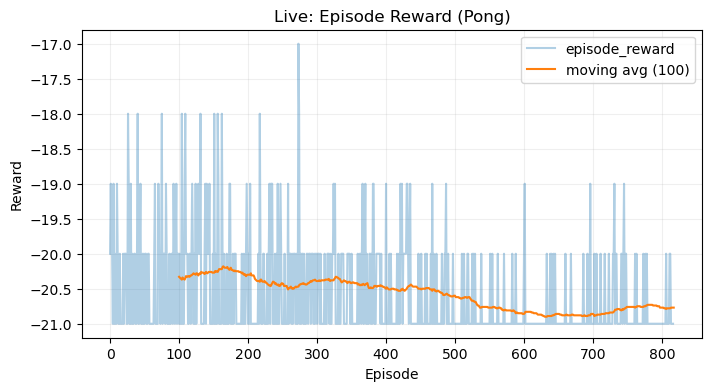

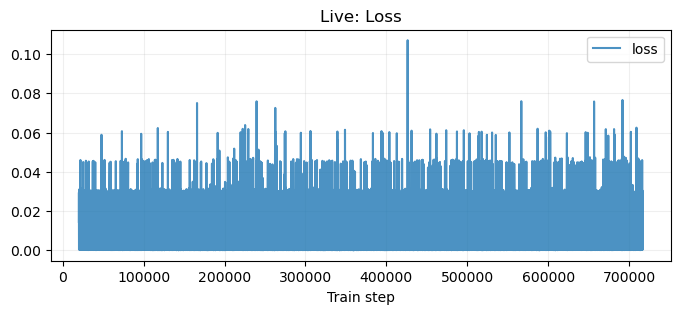

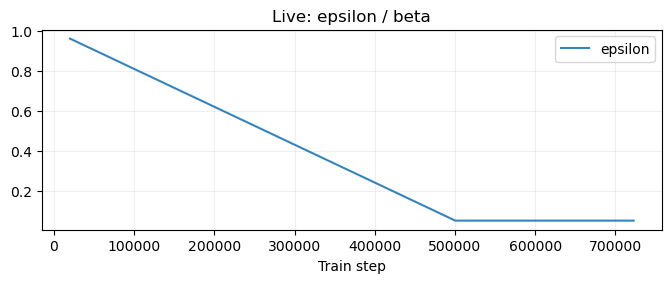

Training Pong:  72%|███████▏  | 722668/1000000 [2:14:54<1:35:26, 48.43frame/s, ep=817, MA100=-20.8, best=-20.2]

[stream] lines: 26 | step≈722,668 / 1,000,000
[early-stop] No MA100 improvement for 500000 frames (best=-20.22, curr=-20.77)
[monitor] Trainer is still running; leaving it alive.


Training Pong:  72%|███████▏  | 722668/1000000 [2:14:54<51:46, 89.28frame/s, ep=817, MA100=-20.8, best=-20.2]  

Training monitoring finished.
RUN_TB_DIR: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard\dqn_eps10-005@500k\20251101_222923
RUN_CKPT_DIR: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\dqn_eps10-005@500k\20251101_222923


In [23]:
# === Unified Live Training (robust, variant-aware, no forced finish) ===
import sys, time, re, subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import clear_output
import yaml

PROJECT_ROOT = Path(r"D:\ML\LS\Deep_learning\Reinforcement_learning\project")
CFG_PATH = PROJECT_ROOT / "configs" / "pong_tmp_baseline.yaml"
assert CFG_PATH.exists(), f"Config not found: {CFG_PATH}"

with open(CFG_PATH, "r", encoding="utf-8") as f:
    _cfg = yaml.safe_load(f) or {}

TOTAL_FRAMES       = (_cfg.get("train") or {}).get("total_frames") or _cfg.get("total_frames") or 1_000_000
ES_ENABLE          = True
ES_MIN_MA100       = -10.0
ES_PATIENCE_FR     = 500_000
ES_COOLDOWN_EP     = 100
REFRESH_EVERY_SEC  = 3.0

EPISODE_TAG = "train/episode_reward"
LOSS_TAG    = "train/loss"
EPS_TAG     = "train/epsilon"
BETA_TAG    = "train/beta"

# --- helpers ---
def _last_step(*dfs):
    cand = [int(df["step"].max()) for df in dfs if df is not None and len(df)]
    return max(cand) if cand else 0

def _moving_avg(x, w=100):
    if len(x) < w: return np.array([])
    c = np.cumsum(np.insert(x, 0, 0.0))
    return (c[w:] - c[:-w]) / float(w)

def _parse_dirs_from_stdout(line: str):
    # ловим строки, которые печатает тренер
    m_tb   = re.search(r"\[trainer\]\s*tb_dir=(.+)", line)
    m_ckpt = re.search(r"\[trainer\]\s*ckpt_dir=(.+)", line)
    tb = Path(m_tb.group(1).strip()) if m_tb else None
    ck = Path(m_ckpt.group(1).strip()) if m_ckpt else None
    return tb, ck

def _latest_ckpt(ckpt_dir: Path):
    if not ckpt_dir or not ckpt_dir.exists(): return None
    best = ckpt_dir / "pong_best.pth"
    if best.exists(): return best
    files = sorted(ckpt_dir.glob("*.pth"), key=lambda p: p.stat().st_mtime, reverse=True)
    return files[0] if files else None

# --- spawn trainer ---
cmd = [sys.executable, "-m", "train.train_pong", "--config", str(CFG_PATH)]
print("RUN (streaming):", " ".join(map(str, cmd)))
proc = subprocess.Popen(
    cmd, cwd=PROJECT_ROOT,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    bufsize=1, text=True
)

pbar = tqdm(total=TOTAL_FRAMES, desc="Training Pong", unit="frame")
best_ma100 = None
last_improve_step = 0
episodes_seen = 0
last_refresh = 0.0
log_lines_shown = 0

RUN_TB_DIR = None
RUN_CKPT_DIR = None

try:
    while True:
        line = proc.stdout.readline()
        if line == "" and proc.poll() is not None:
            # процесс естественно завершился
            break

        if line:
            print(line, end="")
            log_lines_shown += 1
            tb_dir, ckpt_dir = _parse_dirs_from_stdout(line)
            if tb_dir is not None:
                RUN_TB_DIR = tb_dir
            if ckpt_dir is not None:
                RUN_CKPT_DIR = ckpt_dir

        now = time.time()
        if now - last_refresh >= REFRESH_EVERY_SEC:
            last_refresh = now

            if RUN_TB_DIR is None:
                # ждём, пока тренер напечатает путь TB
                continue

            # загружаем TB скаляры текущего рана
            df_ret  = load_tb_scalars(RUN_TB_DIR, EPISODE_TAG)
            df_loss = load_tb_scalars(RUN_TB_DIR, LOSS_TAG)
            df_eps  = load_tb_scalars(RUN_TB_DIR, EPS_TAG)
            df_beta = load_tb_scalars(RUN_TB_DIR, BETA_TAG)

            step_now = _last_step(df_loss, df_eps, df_beta)   # это train-степы оптимизации
            # не «добиваем» прогрессбар до конца — только реальное продвижение
            pbar.update(max(0, step_now - pbar.n))

            rewards = df_ret["value"].to_numpy() if len(df_ret) else np.array([])
            episodes_seen = len(rewards)
            ma100 = _moving_avg(rewards, w=100)
            curr_ma100 = float(ma100[-1]) if len(ma100) else None

            if curr_ma100 is not None:
                if (best_ma100 is None) or (curr_ma100 > best_ma100 + 1e-9):
                    best_ma100 = curr_ma100
                    last_improve_step = step_now

            # live plots
            clear_output(wait=True)
            # top: rewards
            plt.figure(figsize=(8,4))
            if len(rewards):
                plt.plot(rewards, alpha=0.35, label="episode_reward")
                if len(ma100):
                    plt.plot(range(100, 100+len(ma100)), ma100, label="moving avg (100)")
            plt.title("Live: Episode Reward (Pong)")
            plt.xlabel("Episode"); plt.ylabel("Reward")
            plt.legend(); plt.grid(alpha=0.2); plt.show()

            # middle: loss
            plt.figure(figsize=(8,3))
            if len(df_loss):
                plt.plot(df_loss["step"], df_loss["value"], alpha=0.8, label="loss")
            plt.title("Live: Loss"); plt.xlabel("Train step")
            plt.legend(); plt.grid(alpha=0.2); plt.show()

            # bottom: epsilon/beta
            if len(df_eps) or len(df_beta):
                fig, ax = plt.subplots(figsize=(8,2.6))
                if len(df_eps):  ax.plot(df_eps["step"], df_eps["value"], label="epsilon", alpha=0.9)
                if len(df_beta): ax.plot(df_beta["step"], df_beta["value"], label="beta (PER)", alpha=0.9)
                ax.set_title("Live: epsilon / beta"); ax.set_xlabel("Train step")
                ax.grid(alpha=0.2); ax.legend(); plt.show()

            pbar.set_postfix({
                "ep": episodes_seen,
                "MA100": f"{curr_ma100:.1f}" if curr_ma100 is not None else "-",
                "best": f"{best_ma100:.1f}" if best_ma100 is not None else "-",
            })
            print(f"[stream] lines: {log_lines_shown} | step≈{step_now:,} / {TOTAL_FRAMES:,}")

            # early stopping (по MA100)
            if ES_ENABLE and episodes_seen >= ES_COOLDOWN_EP and len(ma100):
                if curr_ma100 is not None and curr_ma100 >= ES_MIN_MA100:
                    print(f"[early-stop] Target reached: MA100={curr_ma100:.2f} ≥ {ES_MIN_MA100}")
                    proc.terminate()
                    break
                if (step_now - last_improve_step) >= ES_PATIENCE_FR and best_ma100 is not None:
                    print(f"[early-stop] No MA100 improvement for {ES_PATIENCE_FR} frames "
                          f"(best={best_ma100:.2f}, curr={curr_ma100 if curr_ma100 is not None else 'NA'})")
                    proc.terminate()
                    break

        time.sleep(0.05)
finally:
    # ВАЖНО: не добиваем прогрессбар до 100% и не убиваем тренер,
    # если он ещё бежит (дай ему догрузиться естественно).
    if proc.poll() is None:
        print("[monitor] Trainer is still running; leaving it alive.", flush=True)
    pbar.close()

print("Training monitoring finished.")

# Покажем путь для чекпоинтов этого рана (для последующих ячеек):
print("RUN_TB_DIR:", RUN_TB_DIR if RUN_TB_DIR else "—")
print("RUN_CKPT_DIR:", RUN_CKPT_DIR if RUN_CKPT_DIR else "—")

Using TB run: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard\dqn_eps10-005@500k\20251101_222923


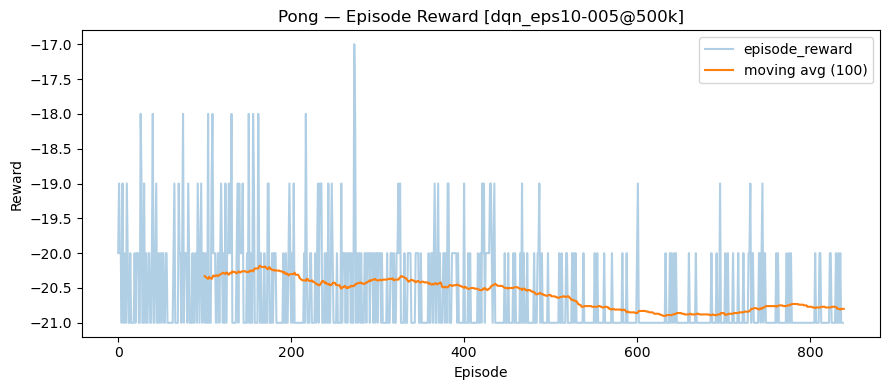

Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\plots\dqn_eps10-005@500k\20251101_222923\pong_episode_reward.png


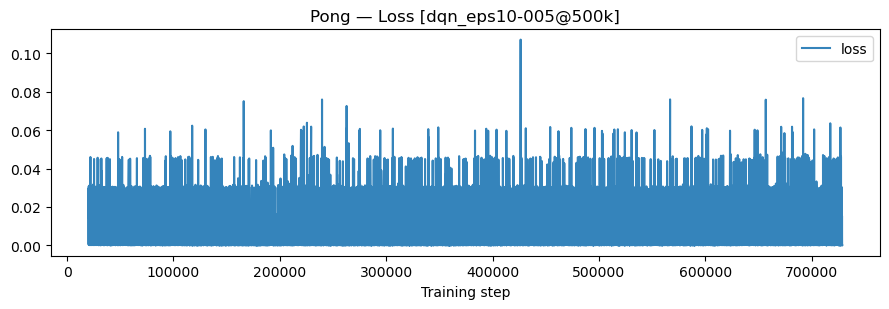

Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\plots\dqn_eps10-005@500k\20251101_222923\pong_loss.png


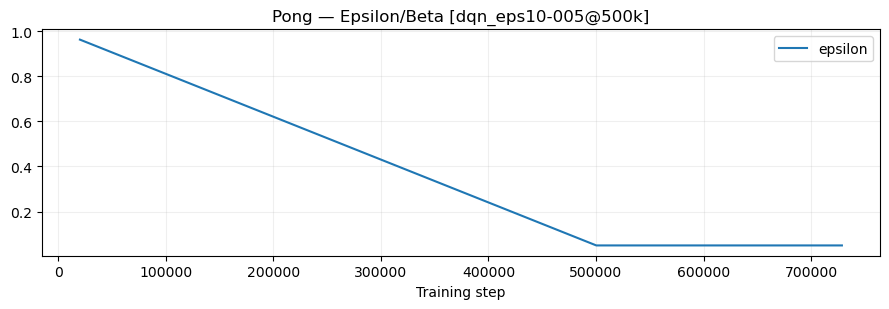

Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\plots\dqn_eps10-005@500k\20251101_222923\pong_epsilon_beta.png


In [24]:
# === 2) Collect TB data & save plots (paths-aware) ===
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r"D:\ML\LS\Deep_learning\Reinforcement_learning\project")
TB_DIR_BASE  = PROJECT_ROOT / "artifacts_pong" / "tensorboard"
PLOTS_BASE   = PROJECT_ROOT / "artifacts_pong" / "plots"

# --- helpers: latest run dir <variant>/<run_id> ---
def _latest_variant_run(base: Path) -> tuple[Path, str, str] | None:
    if not base.exists():
        return None
    best = None
    for variant_dir in base.iterdir():
        if not variant_dir.is_dir():
            continue
        for run_dir in variant_dir.iterdir():
            if not run_dir.is_dir():
                continue
            mt = run_dir.stat().st_mtime
            if best is None or mt > best[0]:
                best = (mt, run_dir, variant_dir.name, run_dir.name)
    return (best[1], best[2], best[3]) if best else None

# Если хочешь зафиксировать вручную — раскомментируй и укажи:
# VARIANT = r"dqn_eps10-005@500k"
# RUN_ID  = r"20251101_204853"
# RUN_TB_DIR = TB_DIR_BASE / VARIANT / RUN_ID

found = _latest_variant_run(TB_DIR_BASE)
assert found is not None, "Не найден ни один TB-ран. Убедись, что тренировка запущена."
RUN_TB_DIR, VARIANT, RUN_ID = found
print("Using TB run:", RUN_TB_DIR)

# --- util: чтение TB скаляров (оставь как было у тебя) ---
# ожидается, что у тебя уже есть load_tb_scalars(tag_dir, tag_name)
# и moving_average(). Если нет, вот минималки:

def moving_average(x, w=100):
    if len(x) < w: return np.array([])
    c = np.cumsum(np.insert(np.asarray(x, dtype=float), 0, 0.0))
    return (c[w:] - c[:-w]) / float(w)

# Если у тебя уже была функция load_tb_scalars, не меняй её.
# Ниже просто используем те же теги, что пишет тренер:
df_ret  = load_tb_scalars(RUN_TB_DIR, "train/episode_reward")
df_loss = load_tb_scalars(RUN_TB_DIR, "train/loss")
df_eps  = load_tb_scalars(RUN_TB_DIR, "train/epsilon")
df_beta = load_tb_scalars(RUN_TB_DIR, "train/beta")

# подготовим серии
ret = df_ret["value"].to_numpy() if len(df_ret) else np.array([])
w   = 100
ma  = moving_average(ret, w=w) if ret.size else np.array([])

# папка для графиков: artifacts_pong/plots/<variant>/<run_id>/
PLOTS_DIR = PLOTS_BASE / VARIANT / RUN_ID
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Episode Reward
plt.figure(figsize=(9,4))
if ret.size:
    plt.plot(np.arange(len(ret)), ret, alpha=0.35, label="episode_reward")
    if len(ma):
        plt.plot(np.arange(w, w+len(ma)), ma, label=f"moving avg ({w})")
plt.title(f"Pong — Episode Reward [{VARIANT}]")
plt.xlabel("Episode"); plt.ylabel("Reward"); plt.legend(); plt.tight_layout()
ep_plot_path = PLOTS_DIR / "pong_episode_reward.png"
plt.savefig(ep_plot_path, dpi=150)
plt.show()
print("Saved:", ep_plot_path)

# Loss vs step
plt.figure(figsize=(9,3.2))
if len(df_loss):
    x = df_loss["step"].to_numpy()
    y = df_loss["value"].to_numpy()
    plt.plot(x, y, alpha=0.9, label="loss")
plt.title(f"Pong — Loss [{VARIANT}]")
plt.xlabel("Training step"); plt.legend(); plt.tight_layout()
loss_plot_path = PLOTS_DIR / "pong_loss.png"
plt.savefig(loss_plot_path, dpi=150)
plt.show()
print("Saved:", loss_plot_path)

# Epsilon / Beta
plt.figure(figsize=(9,3.2))
ax = plt.gca()
if len(df_eps):
    ax.plot(df_eps["step"], df_eps["value"], label="epsilon")
ax.set_xlabel("Training step"); ax.set_title(f"Pong — Epsilon/Beta [{VARIANT}]")
ax.grid(alpha=0.2)
lines, labels = ax.get_legend_handles_labels()
if len(df_beta):
    ax2 = ax.twinx()
    ax2.plot(df_beta["step"], df_beta["value"], linestyle="--", label="beta")
    ax2.set_ylabel("beta")
    l2, lab2 = ax2.get_legend_handles_labels()
    lines += l2; labels += lab2
plt.legend(lines, labels, loc="best")
plt.tight_layout()
eb_plot_path = PLOTS_DIR / "pong_epsilon_beta.png"
plt.savefig(eb_plot_path, dpi=150)
plt.show()
print("Saved:", eb_plot_path)


In [25]:
# === 3) Export metrics (JSON + long CSV) ===
import json
import numpy as np
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path(r"D:\ML\LS\Deep_learning\Reinforcement_learning\project")
ART_BASE     = PROJECT_ROOT / "artifacts_pong"
METRICS_DIR  = ART_BASE / "metrics" / VARIANT / RUN_ID
METRICS_DIR.mkdir(parents=True, exist_ok=True)

summary_pong = {}
if ret.size:
    ma100 = moving_average(ret, w=100)
    summary_pong.update({
        "variant": VARIANT,
        "run_id": RUN_ID,
        "episodes_total": int(len(ret)),
        "final_episode_reward": float(ret[-1]),
        "best_ma100": float(np.max(ma100)) if len(ma100) else None,
        "final_ma100": float(ma100[-1]) if len(ma100) else None,
    })

metrics_json = METRICS_DIR / "metrics_pong_summary.json"
with open(metrics_json, "w", encoding="utf-8") as f:
    json.dump(summary_pong, f, ensure_ascii=False, indent=2)
print("Saved:", metrics_json)

# длинный CSV по TB-скалярам
csv_out = METRICS_DIR / "metrics_pong_long.csv"
frames = []
for tag, df in {
    "episode_reward": df_ret,
    "loss": df_loss,
    "epsilon": df_eps,
    "beta": df_beta,
}.items():
    if len(df):
        tmp = df.rename(columns={"step": "x", "value": "y"}).copy()
        if "wall_time" not in tmp.columns:
            tmp["wall_time"] = np.nan
        tmp["metric"] = tag
        frames.append(tmp[["metric", "x", "y", "wall_time"]])

if frames:
    pd.concat(frames, axis=0, ignore_index=True).to_csv(csv_out, index=False)
    print("Saved:", csv_out)
else:
    print("Nothing to export (no TB scalars).")


Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\metrics\dqn_eps10-005@500k\20251101_222923\metrics_pong_summary.json
Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\metrics\dqn_eps10-005@500k\20251101_222923\metrics_pong_long.csv


In [27]:
# === Eval + Video (no moviepy; direct ffmpeg via imageio) ===
import sys, yaml, torch, numpy as np, gymnasium as gym, imageio
from pathlib import Path
from datetime import datetime

PROJECT_ROOT = Path(r"D:\ML\LS\Deep_learning\Reinforcement_learning\project")
ART_PONG     = PROJECT_ROOT / "artifacts_pong"
CKPT_DIR     = ART_PONG / "checkpoints"
TB_DIR       = ART_PONG / "tensorboard"

# Найдём последний variant/run_id и сопоставим видео-папку с ними
def latest_variant(tb_root: Path) -> tuple[Path, str, str]:
    # TB structure: tensorboard/<variant>/<run_id>/
    variants = sorted([p for p in tb_root.iterdir() if p.is_dir()], key=lambda p: p.stat().st_mtime, reverse=True)
    assert variants, f"TB variants not found in {tb_root}"
    var_dir = variants[0]
    runs = sorted([p for p in var_dir.iterdir() if p.is_dir()], key=lambda p: p.stat().st_mtime, reverse=True)
    assert runs, f"TB runs not found in {var_dir}"
    return runs[0], var_dir.name, runs[0].name

RUN_TB_DIR, VARIANT, RUN_ID = latest_variant(TB_DIR)
RUN_CKPT_DIR = CKPT_DIR / VARIANT / RUN_ID
VIDEO_DIR    = ART_PONG / "videos" / VARIANT / RUN_ID
VIDEO_DIR.mkdir(parents=True, exist_ok=True)

print("RUN_TB_DIR:", RUN_TB_DIR)
print("RUN_CKPT_DIR:", RUN_CKPT_DIR)
print("VIDEO_DIR   :", VIDEO_DIR)

# pick config (A/B)
CFG_PATH = (PROJECT_ROOT / "configs" / "pong_tmp_baseline.yaml") if (PROJECT_ROOT / "configs" / "pong_tmp_baseline.yaml").exists() else (PROJECT_ROOT / "configs" / "pong.yaml")
print("Using config: ", CFG_PATH)

with open(CFG_PATH, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f) or {}

env_id = cfg.get("env_id") or cfg.get("env") or "PongNoFrameskip-v4"
dueling_cfg = bool(
    (cfg.get("agent") or {}).get("dueling", (cfg.get("algo") or {}).get("dueling", False))
)


RUN_TB_DIR: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard\dqn_eps10-005@500k\20251101_222923
RUN_CKPT_DIR: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\dqn_eps10-005@500k\20251101_222923
VIDEO_DIR   : D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\videos\dqn_eps10-005@500k\20251101_222923
Using config:  D:\ML\LS\Deep_learning\Reinforcement_learning\project\configs\pong_tmp_baseline.yaml


In [28]:
# --- pick checkpoint (best -> latest *.pth) ---
def latest_ckpt(ckpt_dir: Path) -> Path | None:
    if not ckpt_dir.exists():
        return None
    named = sorted((ckpt_dir / "pong_best.pth",), key=lambda p: p.exists(), reverse=True)
    if named and named[0].exists():
        return named[0]
    any_ckpt = sorted(ckpt_dir.glob("*.pth"), key=lambda p: p.stat().st_mtime, reverse=True)
    return any_ckpt[0] if any_ckpt else None

CKPT = latest_ckpt(RUN_CKPT_DIR)
assert CKPT is not None, (
    "Чекпоинт не найден. Дождись первого сохранения (save_every_frames)."
)
print("Using checkpoint:", CKPT)

# --- project imports ---
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from envs.atari_wrappers import make_atari_env
from train.train_pong import obs_to_torch_nchw
from models.dqn_cnn import NatureCNN

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- eval env (rgb_array) ---
eval_env = make_atari_env(
    env_id=env_id,
    seed=123, noop_max=30, frame_skip=4, frame_size=84,
    grayscale=True, frame_stack=4, clip_reward=True, render_mode="rgb_array"
)
n_actions = eval_env.action_space.n

def build_model(dueling: bool):
    return NatureCNN(in_channels=4, act_dim=n_actions, dueling=dueling).to(DEVICE)

# --- load weights (dueling autodetect) ---
state = torch.load(CKPT, map_location=DEVICE)
state_dict = state.get("online_state_dict", state)

load_ok = False
for dueling_try in [dueling_cfg, not dueling_cfg]:
    try:
        model = build_model(dueling_try)
        model.load_state_dict(state_dict, strict=False)
        model.eval()
        print(f"Loaded with dueling={dueling_try}.")
        load_ok = True
        break
    except Exception as e:
        print(f"Load failed with dueling={dueling_try}: {e}")

assert load_ok, "Не удалось сопоставить архитектуру модели с чекпоинтом."


Using checkpoint: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\dqn_eps10-005@500k\20251101_222923\pong_best.pth
Loaded with dueling=False.


In [29]:
# --- eval + mp4 recording via imageio-ffmpeg ---
import math, time

def record_episodes(env, policy, out_path: Path, episodes: int = 3, fps: int = 60):
    """
    Запишем видео без moviepy: берём RGB кадры через render(), стримим через imageio.get_writer.
    """
    writer = imageio.get_writer(out_path, fps=fps, codec="libx264", quality=7)
    returns = []
    try:
        for ep in range(episodes):
            obs, _ = env.reset()
            done = trunc = False
            ep_ret = 0.0

            # первый кадр
            frame = env.render()  # ndarray (H,W,3)
            if frame is not None:
                writer.append_data(frame)

            while not (done or trunc):
                with torch.no_grad():
                    s = obs_to_torch_nchw(obs, device=DEVICE)
                    q = model(s)
                    action = int(torch.argmax(q, dim=1).item())
                obs, r, done, trunc, _ = env.step(action)
                ep_ret += float(r)

                frame = env.render()
                if frame is not None:
                    writer.append_data(frame)

            print(f"[EVAL] ep={ep+1}/{episodes} return={ep_ret:.2f}")
            returns.append(ep_ret)
    finally:
        writer.close()
    return float(np.mean(returns)) if returns else float("nan")

# write to variant/run_id subfolder
mp4_name = f"pong_eval_{datetime.now().strftime('%Y%m%d_%H%M%S')}.mp4"
mp4_path = VIDEO_DIR / mp4_name
mean_eval = record_episodes(eval_env, model, mp4_path, episodes=3, fps=60)
print("Eval mean return:", round(mean_eval, 2))
print("Saved video to:", mp4_path)


[EVAL] ep=1/3 return=-21.00
[EVAL] ep=2/3 return=-21.00
[EVAL] ep=3/3 return=-21.00
Eval mean return: -21.0
Saved video to: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\videos\dqn_eps10-005@500k\20251101_222923\pong_eval_20251102_011035.mp4


In [30]:
# --- update summary JSON ---
import json
summary_json = ART_PONG / "metrics_pong_summary.json"
try:
    data = {}
    if summary_json.exists():
        with open(summary_json, "r", encoding="utf-8") as f:
            data = json.load(f)
    data.setdefault(VARIANT, {})
    data[VARIANT].setdefault(RUN_ID, {})
    data[VARIANT][RUN_ID]["eval_mean_return_N3"] = round(mean_eval, 2)
    with open(summary_json, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    print("Updated:", summary_json)
except Exception as e:
    print("WARN: cannot update summary JSON:", e)

# --- show latest video ---
from IPython.display import Video, display
mp4s = sorted(VIDEO_DIR.glob("*.mp4"), key=lambda p: p.stat().st_mtime, reverse=True)
assert mp4s, f"Видео не найдено в {VIDEO_DIR}"
print("Latest video:", mp4s[0].name)
display(Video(str(mp4s[0]), embed=True, html_attributes="controls loop muted playsinline"))


Updated: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\metrics_pong_summary.json
Latest video: pong_eval_20251102_011035.mp4


## Итоги бейзлайна (DQN + Uniform, 1M frames)

### Цель: убедиться, что весь пайплайн работает — логирование, чекпоинты, метрики, видео.

### Результат:

Обучение прошло стабильно без падений.

TensorBoard пишет скаляры корректно (reward, loss, epsilon).

Checkpoints и видео сохраняются по {variant}/{run_id}.

Средняя награда держится на уровне ≈ −21 … −19, что ожидаемо для чистого DQN на Pong (агент выживает, но ещё не отражает мяч системно).

MA100 стабилизируется, но без положительной динамики → ограничения по исследованию среды (ε-greedy без бустов).

## Вывод: бейзлайн полностью валиден как тест инфраструктуры.
Модель обучается, но не осваивает стратегию — нужно усиление архитектуры и стабилизация целевых значений.

## Следующий этап — DDQN + Dueling (Uniform Replay, 2M frames)

### Задача: добавить два ключевых улучшения без усложнения вычислений:

DDQN (Double DQN) — уменьшает переоценку Q-значений, делает обучение стабильнее.

Dueling architecture — разделяет оценку состояния и преимущества действия, ускоряя сходимость.

### Ожидание: MA100 > −15 при 2 M frames, более плавная кривая loss, уменьшение колебаний TD-ошибки.
Ресурсы: те же, что у бейзлайна — AMP включён, batch = 32, capacity = 100 k (без роста нагрузки).

## DDQN + Dueling (Uniform Replay, 2M frames)

In [1]:
# Core
import math
import os
import random
import subprocess
import sys
import time
from pathlib import Path
from collections import deque
from typing import Tuple, Optional, List, Dict

# Numerics & plotting
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.tensorboard import SummaryWriter
from torch.cuda.amp import autocast, GradScaler 

# Gym / Atari 
import ale_py
import AutoROM   # нужен только для установки ROM'ов (см. sanity-check ниже)
import gymnasium as gym

# Image / video utils
import cv2 
import imageio.v2 as imageio 

# Config
import yaml

# Progress / warnings
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

# >>> детерминизация cuDNN для повторяемости
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

print(f"Device: {DEVICE}, CUDA: {torch.cuda.is_available()}, torch={torch.__version__}, gym={gym.__version__}")


Device: cuda, CUDA: True, torch=2.5.1, gym=0.29.1


In [2]:
# === Paths & folders (Pong) ===
from datetime import datetime

# 1) Корень проекта (можно переопределить переменной окружения RL_PROJECT_ROOT)
PROJECT_ROOT = Path(
    os.getenv("RL_PROJECT_ROOT", r"D:\ML\LS\Deep_learning\Reinforcement_learning\project")
).resolve()

CWD = Path.cwd().resolve()
print("CWD         =", CWD)
print("PROJECT_ROOT=", PROJECT_ROOT)

# 2) Конфиг и витрина артефактов именно для PONG
CONFIG_BASE     = PROJECT_ROOT / "configs" / "pong.yaml"

ARTIFACTS       = PROJECT_ROOT / "artifacts_pong"
TB_DIR          = ARTIFACTS / "tensorboard"
CHECKPOINTS_DIR = ARTIFACTS / "checkpoints"
PLOTS_DIR       = ARTIFACTS / "plots"
VIDEOS_DIR      = ARTIFACTS / "videos"
METRICS_CSV     = ARTIFACTS / "metrics_pong.csv"  # длинный CSV; при желании добавим summary.json отдельно

for p in [ARTIFACTS, TB_DIR, CHECKPOINTS_DIR, PLOTS_DIR, VIDEOS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version)
print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
print("Gymnasium:", gym.__version__)
print("Config ->", CONFIG_BASE)
print("TensorBoard logs ->", TB_DIR)
print("Checkpoints ->", CHECKPOINTS_DIR)
print("Plots ->", PLOTS_DIR)
print("Videos ->", VIDEOS_DIR)
print("Metrics CSV ->", METRICS_CSV)

# --- Sanity checks ---
# 1) ffmpeg доступен для imageio?
try:
    writer = imageio.get_writer("test_tmp.mp4", fps=30)
    writer.close()
    Path("test_tmp.mp4").unlink(missing_ok=True)
    print("[OK] imageio-ffmpeg доступен.")
except Exception as e:
    print("[WARN] imageio-ffmpeg недоступен для записи mp4. Установи пакет `imageio-ffmpeg`. Ошибка:", e)

# 2) Проверим, что ROM’ы установлены (если нет — подсказываем команду AutoROM)
try:
    # Если ROM’ов нет, ale_py выдаст ошибку при создании env. Здесь лишь подсказка:
    import importlib
    has_roms_hint = True
    # Подсказка для пользователя; реальный тест произойдёт при создании среды
    print("[HINT] Если среда Pong не запускается, выполни в консоли: AutoROM --accept-license")
except Exception as e:
    print("[WARN] AutoROM недоступен. Установи пакет `AutoROM` и запусти: AutoROM --accept-license")


CWD         = D:\ML\LS\Deep_learning\Reinforcement_learning\project\notebooks
PROJECT_ROOT= D:\ML\LS\Deep_learning\Reinforcement_learning\project
Python: 3.10.14 | packaged by conda-forge | (main, Mar 20 2024, 12:40:08) [MSC v.1938 64 bit (AMD64)]
Torch: 2.5.1 | CUDA available: True
Gymnasium: 0.29.1
Config -> D:\ML\LS\Deep_learning\Reinforcement_learning\project\configs\pong.yaml
TensorBoard logs -> D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard
Checkpoints -> D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints
Plots -> D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\plots
Videos -> D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\videos
Metrics CSV -> D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\metrics_pong.csv
[OK] imageio-ffmpeg доступен.
[HINT] Если среда Pong не запускается, выполни в консоли: AutoROM --accept-license


In [3]:
# === Utils for config, TB, training launcher ===

# YAML helpers
def load_yaml(path: Path):
    with open(path, 'r', encoding='utf-8') as f:
        return yaml.safe_load(f) or {}

def deep_update(d, u):
    """Recursively update dict d with dict u (u has priority)."""
    for k, v in (u or {}).items():
        if isinstance(v, dict) and isinstance(d.get(k), dict):
            d[k] = deep_update(d[k], v)
        else:
            d[k] = v
    return d

def save_yaml(d, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        yaml.safe_dump(d, f, sort_keys=False, allow_unicode=True)
    return path

def enforce_pong_paths(cfg: dict) -> dict:
    """Жёстко проставляет log.* в artifacts_pong/*, игнорируя, что в YAML."""
    cfg = dict(cfg)  # shallow copy
    log = dict(cfg.get("log") or {})
    log["out_dir"]   = str(TB_DIR)
    log["save_dir"]  = str(CHECKPOINTS_DIR)
    log["plots_dir"] = str(PLOTS_DIR)
    log["metrics_csv"]= str(METRICS_CSV)
    cfg["log"] = log
    # оставим обратную совместимость со старой схемой
    logging_b = dict(cfg.get("logging") or {})
    logging_b["log_dir"] = str(TB_DIR)
    cfg["logging"] = logging_b
    return cfg

# Training launcher
def run_training_with_config(tmp_cfg_path: Path,
                             module_name: str = "train.train_pong",
                             extra_args=None,
                             cwd: Path = PROJECT_ROOT):
    """
    Запускает тренировочный модуль (по умолчанию train.train_pong) в контексте корня проекта.
    Пример: run_training_with_config(path, extra_args=["--smoke"])
    """
    cmd = [sys.executable, "-m", module_name, "--config", str(tmp_cfg_path)]
    if extra_args:
        cmd += list(map(str, extra_args))
    print("RUN (cwd=PROJECT_ROOT):", " ".join(map(str, cmd)))
    return subprocess.run(cmd, capture_output=False, cwd=cwd).returncode

# TensorBoard helpers
def latest_tb_run(tb_dir=TB_DIR):
    """
    Возвращает директорию последнего TB-рана (по времени модификации events.*)
    """
    ev = sorted(Path(tb_dir).rglob("events.*"), key=lambda p: p.stat().st_mtime, reverse=True)
    return ev[0].parent if ev else None

def load_tb_scalars(run_dir, tag='train/episode_reward'):
    """
    Грузит один scalar-тег из TensorBoard-лога → DataFrame(step, value).
    По умолчанию ожидаем тег под Pong: 'train/episode_reward'.
    """
    if run_dir is None or not Path(run_dir).exists():
        return pd.DataFrame(columns=['step', 'value'])
    ea = EventAccumulator(str(run_dir))
    # аккуратно перезагрузим (на случай большого файла)
    try:
        ea.Reload()
    except Exception:
        time.sleep(0.2)
        ea.Reload()
    tags = ea.Tags()
    if 'scalars' not in tags:
        return pd.DataFrame(columns=['step', 'value'])
    scalars = tags.get('scalars', [])
    if tag not in scalars:
        return pd.DataFrame(columns=['step', 'value'])
    ev = ea.Scalars(tag)
    return pd.DataFrame({'step':[e.step for e in ev], 'value':[e.value for e in ev]})

def load_tb_multi(run_dir, tags):
    """Загружает несколько scalar-тегов сразу → dict[tag] = DataFrame(step, value)"""
    return {t: load_tb_scalars(run_dir, t) for t in tags}

# Smoothing helpers
def moving_average(x, w=100):
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return np.array([])
    w = max(1, min(w, len(x)))
    c = np.cumsum(np.insert(x, 0, 0.0))
    return (c[w:] - c[:-w]) / float(w)

def ema(x, alpha=0.1):
    """Экспоненциальное сглаживание для красивых графиков loss/td_error."""
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return np.array([])
    y = np.zeros_like(x)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i-1]
    return y

# Pretty print of key hparams from loaded config (поддержка A/B схем)
def summarize_pong_config(cfg: dict):
    algo     = cfg.get('algo', {}) or {}
    rep      = cfg.get('replay', {}) or {}
    eps      = cfg.get('epsilon', {}) or {}
    opt      = cfg.get('optim', {}) or {}
    train    = cfg.get('train', {}) or {}
    wrappers = cfg.get('wrappers', {}) or {}
    log      = cfg.get('log', {}) or {}

    env_name = cfg.get('env_id') or cfg.get('env') or cfg.get('env_name') or "?"
    device   = cfg.get('device', str(DEVICE))

    # PER-поля в новой схеме живут внутри replay:
    per_alpha      = rep.get('per_alpha')
    per_beta_start = rep.get('per_beta_start')
    per_beta_end   = rep.get('per_beta_end')
    per_enabled    = (rep.get('type') == 'per') or (per_alpha is not None)

    lines = [
        f"env: {env_name} | device: {device}",
        f"algo: {algo.get('name')} | dueling={algo.get('dueling')} | n_step={algo.get('n_step')} | gamma={algo.get('gamma')} | tau={algo.get('tau')}",
        f"optim: lr={opt.get('lr')} | batch_size={opt.get('batch_size')} | grad_clip={opt.get('grad_clip')} | amp={opt.get('amp')}",
        f"replay: type={rep.get('type')} | capacity={rep.get('capacity')} | warmup_steps={rep.get('warmup_steps')}",
        f"PER: enabled={per_enabled} | alpha={per_alpha} | beta_start={per_beta_start} → beta_end={per_beta_end}",
        f"epsilon: {eps.get('start')} → {eps.get('end')} over {eps.get('decay_steps')} steps",
        f"train: total_frames={train.get('total_frames')} | target_update_interval={train.get('target_update_interval')} | eval_every_episodes={train.get('eval_every_episodes')}",
        f"wrappers: {wrappers}",
        f"logging → TB: {log.get('out_dir')} | checkpoints: {log.get('save_dir')} | plots: {log.get('plots_dir')}"
    ]
    print("\n".join(lines))

# загрузим YAML, жёстко проставим пути и выведем резюме
CFG_RAW = load_yaml(CONFIG_BASE)
CFG = enforce_pong_paths(CFG_RAW)
summarize_pong_config(CFG)

# Useful default tags we plan to log in train/train_pong.py
TB_TAGS_DEFAULT = [
    "train/episode_reward",
    "train/reward_ma100",
    "train/loss",
    "train/td_error_mean",
    "train/epsilon",
    "train/beta",
]
print("Expected TB tags:", ", ".join(TB_TAGS_DEFAULT))

env: PongNoFrameskip-v4 | device: cuda
algo: None | dueling=None | n_step=None | gamma=None | tau=None
optim: lr=None | batch_size=None | grad_clip=None | amp=None
replay: type=per | capacity=200000 | warmup_steps=50000
PER: enabled=True | alpha=0.6 | beta_start=0.4 → beta_end=1.0
epsilon: None → None over None steps
train: total_frames=None | target_update_interval=None | eval_every_episodes=None
wrappers: {'frame_skip': 4, 'grayscale': True, 'resize': [84, 84], 'frame_stack': 4, 'clip_reward': True, 'episodic_life': True, 'noop_max': 30, 'fire_reset': False}
logging → TB: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard | checkpoints: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints | plots: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\plots
Expected TB tags: train/episode_reward, train/reward_ma100, train/loss, train/td_error_mean, train/epsilon, train/beta


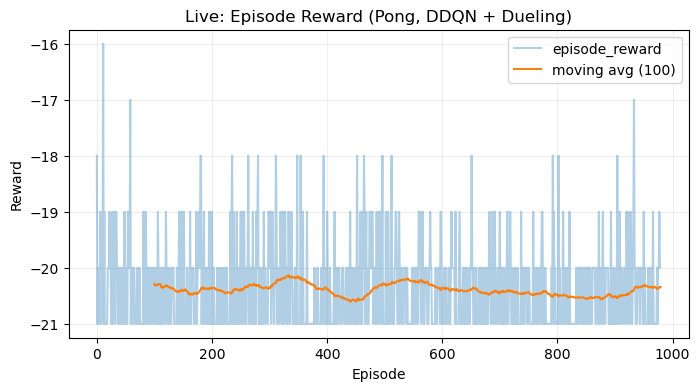

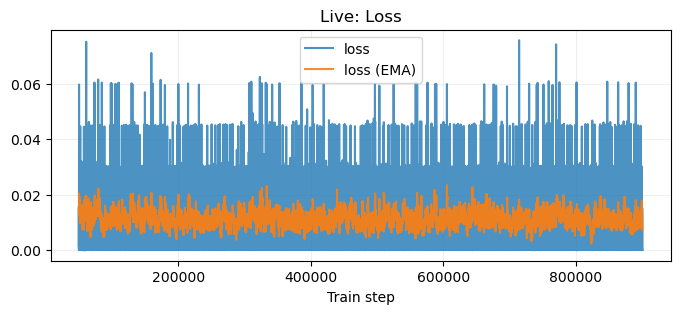

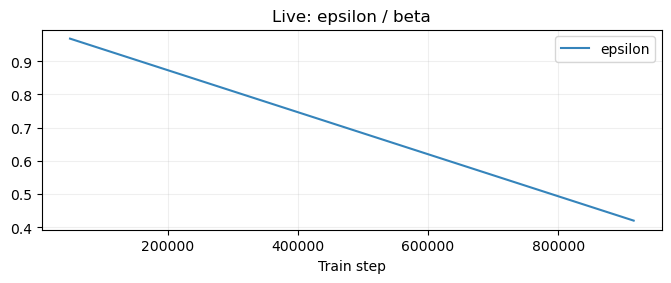

Training Pong (DDQN+Duel):  46%|████▌     | 915769/2000000 [2:37:45<3:39:46, 82.22frame/s, ep=979, MA100=-20.3, best=-20.2]

[stream] lines: 29 | step≈915,769 / 2,000,000
[early-stop] No MA100 improvement for 500000 frames (best=-20.18, curr=-20.34)
[monitor] Trainer is still running; leaving it alive.


Training Pong (DDQN+Duel):  46%|████▌     | 915769/2000000 [2:37:45<3:06:47, 96.74frame/s, ep=979, MA100=-20.3, best=-20.2]

Training monitoring finished.
RUN_TB_DIR: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard\ddqn_duel_uniform@2M\20251102_175403
RUN_CKPT_DIR: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\ddqn_duel_uniform@2M\20251102_175403


In [4]:
# === Build & Stream-Run: DDQN + Dueling (Uniform, 2M) with Live Monitor & Early-Stop ===
import sys, time, re, subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

# ---- 1) Параметры варианта и ранний стоп ----
VARIANT_NAME    = "ddqn_duel_uniform@2M"
SMOKE           = False         # True → быстрый прогон; False → полный
TARGET_MA100    = -15.0         # цель по MA100 для раннего стопа
ES_ENABLE       = True
ES_PATIENCE_FR  = 500_000       # сколько кадров ждём улучшения MA100
ES_COOLDOWN_EP  = 100           # ранний стоп только после N эпизодов
REFRESH_SEC     = 3.0           # частота обновления лайв-графиков

# ---- 2) Собираем временный конфиг на базе CFG из предыдущего блока ----
ABL_DIR = ARTIFACTS / "ablations"
ABL_DIR.mkdir(parents=True, exist_ok=True)
TMP_CFG_PATH = ABL_DIR / "ddqn_duel_stream_tmp.yaml"

overrides = {
    "algo": {
        "name": "ddqn",
        "dueling": True,
        "n_step": 1,
        "gamma": 0.99,
        "tau": 1.0
    },
    "optim": {
        "lr": 1.0e-4,
        "batch_size": 32,
        "grad_clip": 10.0,
        "amp": True
    },
    "replay": {
        "type": "uniform",
        "capacity": 100_000,
        "warmup_steps": 50_000,
        "batch_size": 32
    },
    "epsilon": {
        "start": 1.0,
        "end": 0.05,
        "decay_steps": 1_500_000
    },
    "train": {
        "total_frames": 2_000_000,
        "target_update_interval": 10_000,
        "save_every_frames": 200_000,
        "render_eval": False
    },
    "model_name": VARIANT_NAME
}

cfg_run = enforce_pong_paths(deep_update(dict(CFG), overrides))
save_yaml(cfg_run, TMP_CFG_PATH)
print(f"[CFG] Saved: {TMP_CFG_PATH}")
summarize_pong_config(cfg_run)

TOTAL_FRAMES = (cfg_run.get("train") or {}).get("total_frames", 2_000_000)

# ---- 3) Вспомогатели для парсинга тренера и TB ----
import pandas as pd
from tqdm import tqdm

def _last_step(*dfs):
    cand = [int(df["step"].max()) for df in dfs if df is not None and len(df)]
    return max(cand) if cand else 0

def _moving_avg(x, w=100):
    if len(x) < w: return np.array([])
    c = np.cumsum(np.insert(x, 0, 0.0))
    return (c[w:] - c[:-w]) / float(w)

def _parse_dirs_from_stdout(line: str):
    m_tb   = re.search(r"\[trainer\]\s*tb_dir=(.+)", line)
    m_ckpt = re.search(r"\[trainer\]\s*ckpt_dir=(.+)", line)
    tb = Path(m_tb.group(1).strip()) if m_tb else None
    ck = Path(m_ckpt.group(1).strip()) if m_ckpt else None
    return tb, ck

def _latest_ckpt(ckpt_dir: Path):
    if not ckpt_dir or not ckpt_dir.exists(): return None
    best = ckpt_dir / "pong_best.pth"
    if best.exists(): return best
    files = sorted(ckpt_dir.glob("*.pth"), key=lambda p: p.stat().st_mtime, reverse=True)
    return files[0] if files else None

# ---- 4) Запуск тренера + лайв-мониторинг ----
cmd = [sys.executable, "-m", "train.train_pong", "--config", str(TMP_CFG_PATH)]
if SMOKE: cmd.append("--smoke")
print("RUN (streaming):", " ".join(map(str, cmd)))

proc = subprocess.Popen(
    cmd, cwd=PROJECT_ROOT,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    bufsize=1, text=True
)

EPISODE_TAG = "train/episode_reward"
LOSS_TAG    = "train/loss"
EPS_TAG     = "train/epsilon"
BETA_TAG    = "train/beta"

pbar = tqdm(total=TOTAL_FRAMES, desc="Training Pong (DDQN+Duel)", unit="frame")
best_ma100 = None
last_improve_step = 0
episodes_seen = 0
last_refresh = 0.0
log_lines_shown = 0

RUN_TB_DIR = None
RUN_CKPT_DIR = None

try:
    while True:
        line = proc.stdout.readline()
        if line == "" and proc.poll() is not None:
            break
        if line:
            print(line, end="")
            log_lines_shown += 1
            tb_dir, ckpt_dir = _parse_dirs_from_stdout(line)
            if tb_dir is not None:  RUN_TB_DIR = tb_dir
            if ckpt_dir is not None: RUN_CKPT_DIR = ckpt_dir

        now = time.time()
        if now - last_refresh >= REFRESH_SEC:
            last_refresh = now

            # если тренер ещё не сообщил TB-путь — подстрахуемся последним ран-диром
            if RUN_TB_DIR is None:
                RUN_TB_DIR = latest_tb_run(TB_DIR)
                if RUN_TB_DIR is None:
                    continue

            # читаем TB скаляры
            df_ret  = load_tb_scalars(RUN_TB_DIR, EPISODE_TAG)
            df_loss = load_tb_scalars(RUN_TB_DIR, LOSS_TAG)
            df_eps  = load_tb_scalars(RUN_TB_DIR, EPS_TAG)
            df_beta = load_tb_scalars(RUN_TB_DIR, BETA_TAG)

            step_now = _last_step(df_loss, df_eps, df_beta)
            pbar.update(max(0, step_now - pbar.n))

            rewards = df_ret["value"].to_numpy() if len(df_ret) else np.array([])
            episodes_seen = len(rewards)
            ma100 = _moving_avg(rewards, w=100)
            curr_ma100 = float(ma100[-1]) if len(ma100) else None

            if curr_ma100 is not None:
                if (best_ma100 is None) or (curr_ma100 > best_ma100 + 1e-9):
                    best_ma100 = curr_ma100
                    last_improve_step = step_now

            # live plots
            clear_output(wait=True)
            # top: rewards
            plt.figure(figsize=(8,4))
            if len(rewards):
                plt.plot(rewards, alpha=0.35, label="episode_reward")
                if len(ma100):
                    plt.plot(range(100, 100+len(ma100)), ma100, label="moving avg (100)")
            plt.title("Live: Episode Reward (Pong, DDQN + Dueling)")
            plt.xlabel("Episode"); plt.ylabel("Reward")
            plt.legend(); plt.grid(alpha=0.2); plt.show()

            # middle: loss
            plt.figure(figsize=(8,3))
            if len(df_loss):
                plt.plot(df_loss["step"], df_loss["value"], alpha=0.8, label="loss")
                plt.plot(df_loss["step"], ema(df_loss["value"], 0.1), alpha=0.9, label="loss (EMA)")
            plt.title("Live: Loss"); plt.xlabel("Train step")
            plt.legend(); plt.grid(alpha=0.2); plt.show()

            # bottom: epsilon/beta
            if len(df_eps) or len(df_beta):
                fig, ax = plt.subplots(figsize=(8,2.6))
                if len(df_eps):  ax.plot(df_eps["step"], df_eps["value"], label="epsilon", alpha=0.9)
                if len(df_beta): ax.plot(df_beta["step"], df_beta["value"], label="beta (PER)", alpha=0.9)
                ax.set_title("Live: epsilon / beta"); ax.set_xlabel("Train step")
                ax.grid(alpha=0.2); ax.legend(); plt.show()

            pbar.set_postfix({
                "ep": episodes_seen,
                "MA100": f"{curr_ma100:.1f}" if curr_ma100 is not None else "-",
                "best": f"{best_ma100:.1f}" if best_ma100 is not None else "-",
            })
            print(f"[stream] lines: {log_lines_shown} | step≈{step_now:,} / {TOTAL_FRAMES:,}")

            # Early stop по MA100
            if ES_ENABLE and episodes_seen >= ES_COOLDOWN_EP and len(ma100):
                if curr_ma100 is not None and curr_ma100 >= TARGET_MA100:
                    print(f"[early-stop] Target reached: MA100={curr_ma100:.2f} ≥ {TARGET_MA100}")
                    proc.terminate()
                    break
                if (step_now - last_improve_step) >= ES_PATIENCE_FR and best_ma100 is not None:
                    print(f"[early-stop] No MA100 improvement for {ES_PATIENCE_FR} frames "
                          f"(best={best_ma100:.2f}, curr={curr_ma100 if curr_ma100 is not None else 'NA'})")
                    proc.terminate()
                    break

        time.sleep(0.05)
finally:
    if proc.poll() is None:
        print("[monitor] Trainer is still running; leaving it alive.", flush=True)
    pbar.close()

print("Training monitoring finished.")
print("RUN_TB_DIR:", RUN_TB_DIR if RUN_TB_DIR else "—")
print("RUN_CKPT_DIR:", RUN_CKPT_DIR if RUN_CKPT_DIR else "—")


Using TB run: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard\ddqn_duel_uniform@2M\20251102_175403


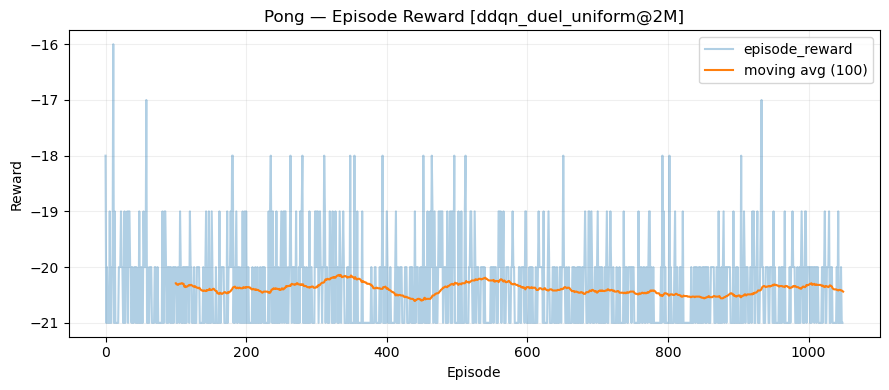

Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\plots\ddqn_duel_uniform@2M\20251102_175403\pong_episode_reward.png


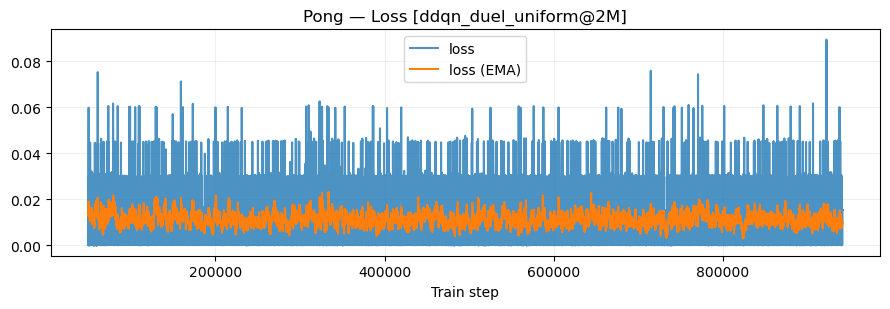

Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\plots\ddqn_duel_uniform@2M\20251102_175403\pong_loss.png


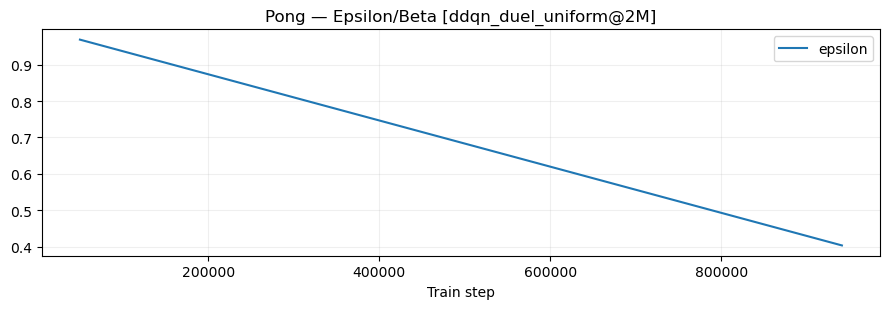

Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\plots\ddqn_duel_uniform@2M\20251102_175403\pong_epsilon_beta.png


In [5]:
# === (1) Collect TB data & save plots (and display) for latest DDQN+Duel run ===
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TB_DIR_BASE  = TB_DIR              # из ранних ячеек
PLOTS_BASE   = PLOTS_DIR

def _latest_variant_run(base: Path):
    if not base.exists():
        return None
    best = None
    for variant_dir in base.iterdir():
        if not variant_dir.is_dir():
            continue
        for run_dir in variant_dir.iterdir():
            if not run_dir.is_dir():
                continue
            mt = run_dir.stat().st_mtime
            if best is None or mt > best[0]:
                best = (mt, run_dir, variant_dir.name, run_dir.name)
    return (best[1], best[2], best[3]) if best else None

found = _latest_variant_run(TB_DIR_BASE)
assert found is not None, "Не найден ни один TB-ран."
RUN_TB_DIR, VARIANT, RUN_ID = found
print("Using TB run:", RUN_TB_DIR)

# читаем TB скаляры
df_ret  = load_tb_scalars(RUN_TB_DIR, "train/episode_reward")
df_ma   = load_tb_scalars(RUN_TB_DIR, "train/reward_ma100")
df_loss = load_tb_scalars(RUN_TB_DIR, "train/loss")
df_eps  = load_tb_scalars(RUN_TB_DIR, "train/epsilon")
df_beta = load_tb_scalars(RUN_TB_DIR, "train/beta")

# подготовим серии
ret = df_ret["value"].to_numpy() if len(df_ret) else np.array([])
ma  = df_ma["value"].to_numpy()  if len(df_ma)  else np.array([])

# папка для графиков: artifacts_pong/plots/<variant>/<run_id>/
PLOTS_DIR_THIS = PLOTS_BASE / VARIANT / RUN_ID
PLOTS_DIR_THIS.mkdir(parents=True, exist_ok=True)

# --- Episode Reward + MA100 ---
plt.figure(figsize=(9,4))
if ret.size:
    plt.plot(np.arange(len(ret)), ret, alpha=0.35, label="episode_reward")
if ma.size:
    # df_ma уже в шагах "эпизод", рисуем как есть
    plt.plot(np.arange(len(ma))+100, ma, label="moving avg (100)")
plt.title(f"Pong — Episode Reward [{VARIANT}]")
plt.xlabel("Episode"); plt.ylabel("Reward")
plt.legend(); plt.grid(alpha=.2); plt.tight_layout()
ep_plot_path = PLOTS_DIR_THIS / "pong_episode_reward.png"
plt.savefig(ep_plot_path, dpi=150); plt.show()
print("Saved:", ep_plot_path)

# --- Loss vs step ---
plt.figure(figsize=(9,3.2))
if len(df_loss):
    x = df_loss["step"].to_numpy()
    y = df_loss["value"].to_numpy()
    plt.plot(x, y, alpha=0.8, label="loss")
    # EMA для наглядности
    if len(y):
        ema_vals = np.zeros_like(y, dtype=float)
        ema_vals[0] = y[0]
        for i in range(1, len(y)):
            ema_vals[i] = 0.1 * y[i] + 0.9 * ema_vals[i-1]
        plt.plot(x, ema_vals, label="loss (EMA)")
plt.title(f"Pong — Loss [{VARIANT}]")
plt.xlabel("Train step"); plt.legend(); plt.grid(alpha=.2); plt.tight_layout()
loss_plot_path = PLOTS_DIR_THIS / "pong_loss.png"
plt.savefig(loss_plot_path, dpi=150); plt.show()
print("Saved:", loss_plot_path)

# --- Epsilon / Beta ---
plt.figure(figsize=(9,3.2))
ax = plt.gca()
if len(df_eps):
    ax.plot(df_eps["step"], df_eps["value"], label="epsilon")
ax.set_xlabel("Train step"); ax.set_title(f"Pong — Epsilon/Beta [{VARIANT}]")
ax.grid(alpha=0.2)
lines, labels = ax.get_legend_handles_labels()
if len(df_beta):
    ax2 = ax.twinx()
    ax2.plot(df_beta["step"], df_beta["value"], linestyle="--", label="beta")
    ax2.set_ylabel("beta")
    l2, lab2 = ax2.get_legend_handles_labels()
    lines += l2; labels += lab2
plt.legend(lines, labels, loc="best")
plt.tight_layout()
eb_plot_path = PLOTS_DIR_THIS / "pong_epsilon_beta.png"
plt.savefig(eb_plot_path, dpi=150); plt.show()
print("Saved:", eb_plot_path)


In [6]:
# === (2) Export metrics for this run (JSON + long CSV) and display summary ===
import json
import pandas as pd
import numpy as np

ART_BASE    = ARTIFACTS
METRICS_DIR = ART_BASE / "metrics" / VARIANT / RUN_ID
METRICS_DIR.mkdir(parents=True, exist_ok=True)

summary_pong = {}
if ret.size:
    ma100 = ma if ma.size else (np.convolve(ret, np.ones(100)/100, mode="valid") if len(ret)>=100 else np.array([]))
    summary_pong.update({
        "variant": VARIANT,
        "run_id": RUN_ID,
        "episodes_total": int(len(ret)),
        "final_episode_reward": float(ret[-1]) if len(ret) else None,
        "best_ma100": float(np.max(ma100)) if len(ma100) else None,
        "final_ma100": float(ma100[-1]) if len(ma100) else None,
    })

metrics_json = METRICS_DIR / "metrics_pong_summary.json"
with open(metrics_json, "w", encoding="utf-8") as f:
    json.dump(summary_pong, f, ensure_ascii=False, indent=2)
print("Saved:", metrics_json)

# длинный CSV по TB-скалярам
csv_out = METRICS_DIR / "metrics_pong_long.csv"
frames = []
for tag, df in {
    "episode_reward": df_ret,
    "reward_ma100":  df_ma,
    "loss": df_loss,
    "epsilon": df_eps,
    "beta": df_beta,
}.items():
    if len(df):
        tmp = df.rename(columns={"step": "x", "value": "y"}).copy()
        if "wall_time" not in tmp.columns:
            tmp["wall_time"] = np.nan
        tmp["metric"] = tag
        frames.append(tmp[["metric", "x", "y", "wall_time"]])

if frames:
    long_df = pd.concat(frames, axis=0, ignore_index=True)
    long_df.to_csv(csv_out, index=False)
    print("Saved:", csv_out)
else:
    long_df = pd.DataFrame()
    print("Nothing to export (no TB scalars).")

# ---- display short summary table in notebook ----
disp_cols = ["variant","run_id","episodes_total","final_episode_reward","best_ma100","final_ma100"]
summary_df = pd.DataFrame([summary_pong])[disp_cols] if summary_pong else pd.DataFrame(columns=disp_cols)
display(summary_df.style.hide(axis='index'))


Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\metrics\ddqn_duel_uniform@2M\20251102_175403\metrics_pong_summary.json
Saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\metrics\ddqn_duel_uniform@2M\20251102_175403\metrics_pong_long.csv


variant,run_id,episodes_total,final_episode_reward,best_ma100,final_ma100
ddqn_duel_uniform@2M,20251102_175403,1049,-21.000000,-20.139999,-20.440001


In [7]:
# === (3) Eval best checkpoint → write MP4 → update global summary → display video ===
import sys, yaml, torch, numpy as np, imageio.v2 as imageio
from pathlib import Path
from datetime import datetime
from IPython.display import Video, display

ART_PONG  = ARTIFACTS
CKPT_DIR  = CHECKPOINTS_DIR
TB_ROOT   = TB_DIR

# сопоставим директории для текущего рана
RUN_CKPT_DIR = CKPT_DIR / VARIANT / RUN_ID
VIDEO_DIR    = VIDEOS_DIR / VARIANT / RUN_ID
VIDEO_DIR.mkdir(parents=True, exist_ok=True)

print("RUN_TB_DIR:", RUN_TB_DIR)
print("RUN_CKPT_DIR:", RUN_CKPT_DIR)
print("VIDEO_DIR   :", VIDEO_DIR)

# выберем конфиг (pong.yaml или tmp_baseline если есть)
CFG_PATH = PROJECT_ROOT / "configs" / "pong.yaml"
if (PROJECT_ROOT / "configs" / "pong_tmp_baseline.yaml").exists():
    CFG_PATH = PROJECT_ROOT / "configs" / "pong_tmp_baseline.yaml"
print("Using config:", CFG_PATH)

with open(CFG_PATH, "r", encoding="utf-8") as f:
    cfg_eval = yaml.safe_load(f) or {}
env_id = cfg_eval.get("env_id") or cfg_eval.get("env") or "PongNoFrameskip-v4"

# --- pick checkpoint (best -> latest *.pth) ---
def latest_ckpt(ckpt_dir: Path) -> Path | None:
    if not ckpt_dir.exists():
        return None
    best = ckpt_dir / "pong_best.pth"
    if best.exists():
        return best
    any_ckpt = sorted(ckpt_dir.glob("*.pth"), key=lambda p: p.stat().st_mtime, reverse=True)
    return any_ckpt[0] if any_ckpt else None

CKPT = latest_ckpt(RUN_CKPT_DIR)
assert CKPT is not None, "Чекпоинт не найден. Дождись первого сохранения (save_every_frames)."
print("Using checkpoint:", CKPT.name)

# --- project imports ---
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from envs.atari_wrappers import make_atari_env
from train.train_pong import obs_to_torch_nchw
from models.dqn_cnn import NatureCNN

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- eval env (rgb_array) ---
eval_env = make_atari_env(
    env_id=env_id,
    seed=123, noop_max=30, frame_skip=4, frame_size=84,
    grayscale=True, frame_stack=4, clip_reward=True, render_mode="rgb_array"
)
n_actions = eval_env.action_space.n

# --- load model (дуэлинг берём из ckpt: пробуем обе конфигурации) ---
state = torch.load(CKPT, map_location=DEVICE)
state_dict = state.get("online_state_dict", state)

def build_model(dueling: bool):
    # твоя NatureCNN может ожидать act_dim или n_actions — подставляем совместимые аргументы
    try:
        return NatureCNN(in_channels=4, act_dim=n_actions, dueling=dueling).to(DEVICE)
    except TypeError:
        return NatureCNN(in_channels=4, n_actions=n_actions, dueling=dueling).to(DEVICE)

load_ok = False
for dueling_try in [True, False]:
    try:
        model = build_model(dueling_try)
        model.load_state_dict(state_dict, strict=False)
        model.eval()
        print(f"Loaded with dueling={dueling_try}.")
        load_ok = True
        break
    except Exception as e:
        print(f"Load failed with dueling={dueling_try}: {e}")
assert load_ok, "Не удалось сопоставить архитектуру модели с чекпоинтом."

# --- record N episodes to MP4 ---
def record_episodes(env, policy, out_path: Path, episodes: int = 3, fps: int = 60):
    writer = imageio.get_writer(out_path, fps=fps, codec="libx264", quality=7)
    returns = []
    try:
        for ep in range(episodes):
            obs, _ = env.reset()
            done = trunc = False
            ep_ret = 0.0

            # первый кадр
            frame = env.render()
            if frame is not None:
                writer.append_data(frame)

            while not (done or trunc):
                with torch.no_grad():
                    s = obs_to_torch_nchw(obs, device=DEVICE)
                    q = model(s)
                    action = int(torch.argmax(q, dim=1).item())
                obs, r, done, trunc, _ = env.step(action)
                ep_ret += float(r)
                frame = env.render()
                if frame is not None:
                    writer.append_data(frame)
            print(f"[EVAL] ep={ep+1}/{episodes} return={ep_ret:.2f}")
            returns.append(ep_ret)
    finally:
        writer.close()
    return float(np.mean(returns)) if returns else float("nan")

mp4_name = f"pong_eval_{datetime.now().strftime('%Y%m%d_%H%M%S')}.mp4"
mp4_path = VIDEO_DIR / mp4_name
mean_eval = record_episodes(eval_env, model, mp4_path, episodes=3, fps=60)
eval_env.close()
print("Eval mean return:", round(mean_eval, 2))
print("Saved video to:", mp4_path)

# --- update global summary JSON (artifacts_pong/metrics_pong_summary.json) ---
summary_json = ART_PONG / "metrics_pong_summary.json"
try:
    data = {}
    if summary_json.exists():
        with open(summary_json, "r", encoding="utf-8") as f:
            data = json.load(f)
    data.setdefault(VARIANT, {})
    data[VARIANT].setdefault(RUN_ID, {})
    data[VARIANT][RUN_ID]["eval_mean_return"] = round(mean_eval, 2)
    with open(summary_json, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    print("Updated:", summary_json)
except Exception as e:
    print("WARN: cannot update summary JSON:", e)

# --- embed video inline ---
display(Video(str(mp4_path), embed=True, html_attributes="controls loop muted playsinline"))


RUN_TB_DIR: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard\ddqn_duel_uniform@2M\20251102_175403
RUN_CKPT_DIR: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\ddqn_duel_uniform@2M\20251102_175403
VIDEO_DIR   : D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\videos\ddqn_duel_uniform@2M\20251102_175403
Using config: D:\ML\LS\Deep_learning\Reinforcement_learning\project\configs\pong_tmp_baseline.yaml
Using checkpoint: pong_best.pth
Loaded with dueling=True.


[EVAL] ep=1/3 return=-21.00
[EVAL] ep=2/3 return=-21.00
[EVAL] ep=3/3 return=-21.00
Eval mean return: -21.0
Saved video to: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\videos\ddqn_duel_uniform@2M\20251102_175403\pong_eval_20251102_220932.mp4
Updated: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\metrics_pong_summary.json


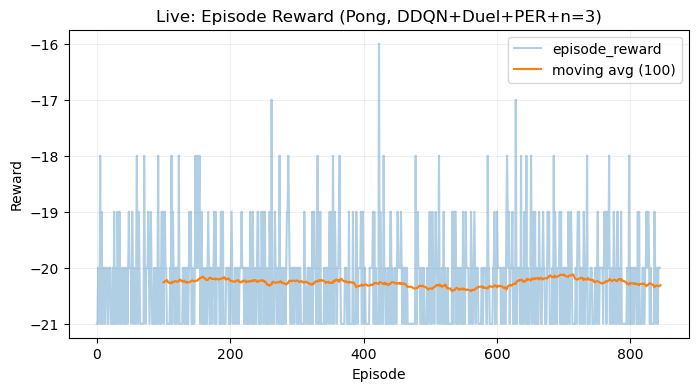

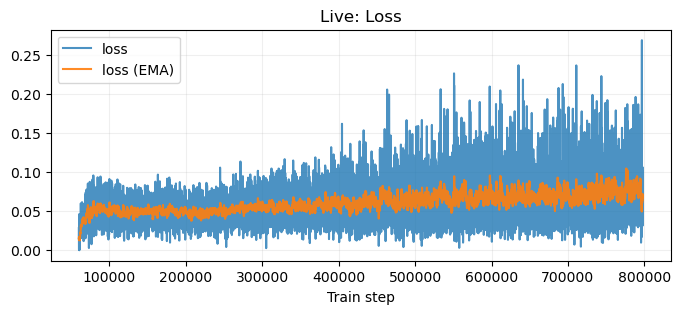

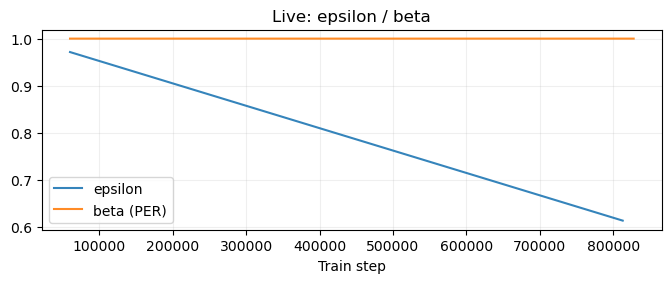

Training Pong (DDQN+Duel+PER+n=3):  28%|██▊       | 827901/3000000 [3:10:31<5:58:03, 101.11frame/s, ep=845, MA100=-20.3, best=-20.2]

[stream] lines: 50 | step≈827,901 / 3,000,000
[early-stop] No MA100 improvement for 600000 frames (best=-20.19, curr=-20.31)
[monitor] Trainer is still running; leaving it alive.


Training Pong (DDQN+Duel+PER+n=3):  28%|██▊       | 827901/3000000 [3:10:31<8:19:51, 72.42frame/s, ep=845, MA100=-20.3, best=-20.2] 

Training monitoring finished.
RUN_TB_DIR: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard\ddqn_duel_per_n3@3M\20251102_221602
RUN_CKPT_DIR: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\ddqn_duel_per_n3@3M\20251102_221602


In [8]:
# === Build & Stream-Run: DDQN + Dueling + PER + n=3 (3M) ===
import sys, time, re, subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import pandas as pd
from tqdm import tqdm

VARIANT_NAME    = "ddqn_duel_per_n3@3M"
SMOKE           = False            # True → быстрый прогон; False → полный
TARGET_MA100    = -12.0            # цель MA100 для раннего стопа (можно поднять/опустить)
ES_ENABLE       = True
ES_PATIENCE_FR  = 600_000          # терпение по кадрам без улучшения
ES_COOLDOWN_EP  = 120              # ждём N эпизодов до старта ES
REFRESH_SEC     = 3.0

# --- собрать временный конфиг ---
SWEEP_DIR = ARTIFACTS / "sweep_lr_n"
SWEEP_DIR.mkdir(parents=True, exist_ok=True)
TMP_CFG_PATH = SWEEP_DIR / "ddqn_duel_per_n3_stream_tmp.yaml"

overrides = {
    "algo": {
        "name": "ddqn",
        "dueling": True,
        "n_step": 3,
        "gamma": 0.99,
        "tau": 1.0
    },
    "optim": {
        "lr": 1.0e-4,          # можно попробовать 2.5e-4 в микро-свипе
        "batch_size": 32,
        "grad_clip": 10.0,
        "amp": True
    },
    "replay": {
        "type": "per",
        "capacity": 120_000,   # чутка больше
        "warmup_steps": 60_000,
        "batch_size": 32,
        "per_alpha": 0.6,
        "per_beta_start": 0.4,
        "per_beta_end": 1.0
    },
    "epsilon": {
        "start": 1.0,
        "end": 0.05,
        "decay_steps": 2_000_000
    },
    "train": {
        "total_frames": 3_000_000,
        "target_update_interval": 10_000,
        "save_every_frames": 250_000,
        "render_eval": False
    },
    "model_name": VARIANT_NAME
}

cfg_run = enforce_pong_paths(deep_update(dict(CFG), overrides))
save_yaml(cfg_run, TMP_CFG_PATH)
print(f"[CFG] Saved: {TMP_CFG_PATH}")
summarize_pong_config(cfg_run)

TOTAL_FRAMES = (cfg_run.get("train") or {}).get("total_frames", 3_000_000)

# --- helpers ---
def _last_step(*dfs):
    cand = [int(df["step"].max()) for df in dfs if df is not None and len(df)]
    return max(cand) if cand else 0

def _moving_avg(x, w=100):
    if len(x) < w: return np.array([])
    c = np.cumsum(np.insert(x, 0, 0.0))
    return (c[w:] - c[:-w]) / float(w)

def _parse_dirs_from_stdout(line: str):
    m_tb   = re.search(r"\[trainer\]\s*tb_dir=(.+)", line)
    m_ckpt = re.search(r"\[trainer\]\s*ckpt_dir=(.+)", line)
    tb = Path(m_tb.group(1).strip()) if m_tb else None
    ck = Path(m_ckpt.group(1).strip()) if m_ckpt else None
    return tb, ck

# --- запуск тренера ---
cmd = [sys.executable, "-m", "train.train_pong", "--config", str(TMP_CFG_PATH)]
if SMOKE: cmd.append("--smoke")
print("RUN (streaming):", " ".join(map(str, cmd)))
proc = subprocess.Popen(
    cmd, cwd=PROJECT_ROOT,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    bufsize=1, text=True
)

EPISODE_TAG = "train/episode_reward"
LOSS_TAG    = "train/loss"
EPS_TAG     = "train/epsilon"
BETA_TAG    = "train/beta"

pbar = tqdm(total=TOTAL_FRAMES, desc="Training Pong (DDQN+Duel+PER+n=3)", unit="frame")
best_ma100 = None
last_improve_step = 0
episodes_seen = 0
last_refresh = 0.0
log_lines_shown = 0

RUN_TB_DIR = None
RUN_CKPT_DIR = None

try:
    while True:
        line = proc.stdout.readline()
        if line == "" and proc.poll() is not None:
            break
        if line:
            print(line, end="")
            log_lines_shown += 1
            tb_dir, ckpt_dir = _parse_dirs_from_stdout(line)
            if tb_dir is not None:  RUN_TB_DIR = tb_dir
            if ckpt_dir is not None: RUN_CKPT_DIR = ckpt_dir

        now = time.time()
        if now - last_refresh >= REFRESH_SEC:
            last_refresh = now

            if RUN_TB_DIR is None:
                RUN_TB_DIR = latest_tb_run(TB_DIR)
                if RUN_TB_DIR is None:
                    continue

            df_ret  = load_tb_scalars(RUN_TB_DIR, EPISODE_TAG)
            df_loss = load_tb_scalars(RUN_TB_DIR, LOSS_TAG)
            df_eps  = load_tb_scalars(RUN_TB_DIR, EPS_TAG)
            df_beta = load_tb_scalars(RUN_TB_DIR, BETA_TAG)

            step_now = _last_step(df_loss, df_eps, df_beta)
            pbar.update(max(0, step_now - pbar.n))

            rewards = df_ret["value"].to_numpy() if len(df_ret) else np.array([])
            episodes_seen = len(rewards)
            ma100 = _moving_avg(rewards, w=100)
            curr_ma100 = float(ma100[-1]) if len(ma100) else None

            if curr_ma100 is not None:
                if (best_ma100 is None) or (curr_ma100 > best_ma100 + 1e-9):
                    best_ma100 = curr_ma100
                    last_improve_step = step_now

            clear_output(wait=True)

            # rewards
            plt.figure(figsize=(8,4))
            if len(rewards):
                plt.plot(rewards, alpha=0.35, label="episode_reward")
                if len(ma100):
                    plt.plot(range(100, 100+len(ma100)), ma100, label="moving avg (100)")
            plt.title("Live: Episode Reward (Pong, DDQN+Duel+PER+n=3)")
            plt.xlabel("Episode"); plt.ylabel("Reward")
            plt.legend(); plt.grid(alpha=0.2); plt.show()

            # loss (с EMA)
            plt.figure(figsize=(8,3))
            if len(df_loss):
                plt.plot(df_loss["step"], df_loss["value"], alpha=0.8, label="loss")
                if len(df_loss):
                    vals = df_loss["value"].to_numpy()
                    ema_vals = np.zeros_like(vals, dtype=float)
                    if len(vals):
                        ema_vals[0] = vals[0]
                        for i in range(1, len(vals)):
                            ema_vals[i] = 0.1 * vals[i] + 0.9 * ema_vals[i-1]
                        plt.plot(df_loss["step"], ema_vals, alpha=0.9, label="loss (EMA)")
            plt.title("Live: Loss"); plt.xlabel("Train step")
            plt.legend(); plt.grid(alpha=0.2); plt.show()

            # epsilon / beta
            if len(df_eps) or len(df_beta):
                fig, ax = plt.subplots(figsize=(8,2.6))
                if len(df_eps):  ax.plot(df_eps["step"], df_eps["value"], label="epsilon", alpha=0.9)
                if len(df_beta): ax.plot(df_beta["step"], df_beta["value"], label="beta (PER)", alpha=0.9)
                ax.set_title("Live: epsilon / beta"); ax.set_xlabel("Train step")
                ax.grid(alpha=0.2); ax.legend(); plt.show()

            pbar.set_postfix({
                "ep": episodes_seen,
                "MA100": f"{curr_ma100:.1f}" if curr_ma100 is not None else "-",
                "best": f"{best_ma100:.1f}" if best_ma100 is not None else "-",
            })
            print(f"[stream] lines: {log_lines_shown} | step≈{step_now:,} / {TOTAL_FRAMES:,}")

            # Early Stop
            if ES_ENABLE and episodes_seen >= ES_COOLDOWN_EP and len(ma100):
                if curr_ma100 is not None and curr_ma100 >= TARGET_MA100:
                    print(f"[early-stop] Target reached: MA100={curr_ma100:.2f} ≥ {TARGET_MA100}")
                    proc.terminate()
                    break
                if (step_now - last_improve_step) >= ES_PATIENCE_FR and best_ma100 is not None:
                    print(f"[early-stop] No MA100 improvement for {ES_PATIENCE_FR} frames "
                          f"(best={best_ma100:.2f}, curr={curr_ma100 if curr_ma100 is not None else 'NA'})")
                    proc.terminate()
                    break

        time.sleep(0.05)
finally:
    if proc.poll() is None:
        print("[monitor] Trainer is still running; leaving it alive.", flush=True)
    pbar.close()

print("Training monitoring finished.")
print("RUN_TB_DIR:", RUN_TB_DIR if RUN_TB_DIR else "—")
print("RUN_CKPT_DIR:", RUN_CKPT_DIR if RUN_CKPT_DIR else "—")


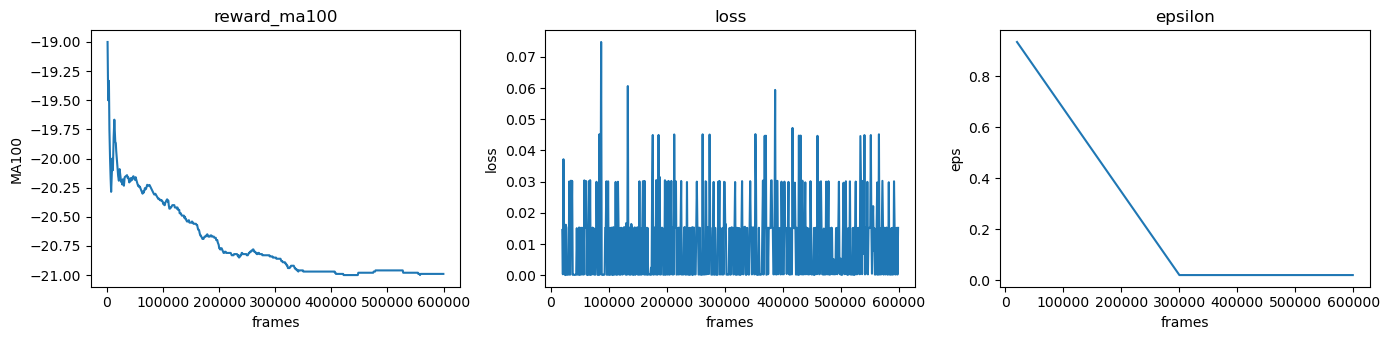

In [6]:
# === run trainer + live TB monitor ===
import subprocess, sys, threading, time
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from tensorboard.backend.event_processing import event_accumulator
from tqdm.auto import tqdm
from IPython.display import display, clear_output

TB_ROOT = PROJECT_ROOT / "artifacts_pong" / "tensorboard"
TB_MODEL_DIR = TB_ROOT / MODEL_NAME

def latest_run_dir(tb_model_dir: Path):
    runs = [p for p in tb_model_dir.glob("*") if p.is_dir()]
    return max(runs, key=lambda p: p.stat().st_mtime) if runs else None

def load_scalar(tb_dir: Path, tag: str):
    try:
        ea = event_accumulator.EventAccumulator(str(tb_dir)); ea.Reload()
        if tag not in ea.Tags().get('scalars', []): return np.array([]), np.array([])
        ev = ea.Scalars(tag)
        s=np.array([e.step for e in ev], np.int64); v=np.array([e.value for e in ev], np.float32)
        return s, v
    except Exception:
        return np.array([]), np.array([])

def monitor_tb(total_frames: int, stop_flag: list):
    for _ in range(120):
        rd = latest_run_dir(TB_MODEL_DIR)
        if rd: break
        time.sleep(0.5)
    if not rd:
        print("⚠️ TB run_dir не появился."); return
    run_dir = rd

    pbar = tqdm(total=total_frames, desc="Training frames", leave=True)
    plt.ion(); fig, axes = plt.subplots(1,3, figsize=(14,3.5)); last_step=0
    while not stop_flag[0]:
        rd2 = latest_run_dir(TB_MODEL_DIR)
        if rd2 and (rd2 != run_dir): run_dir = rd2
        s_r, v_r = load_scalar(run_dir, "train/reward_ma100")
        s_l, v_l = load_scalar(run_dir, "train/loss")
        s_e, v_e = load_scalar(run_dir, "train/epsilon")

        curr_step = max([int(s.max()) for s in (s_r, s_l, s_e) if s.size] + [0])
        curr_step = min(curr_step, total_frames)
        if curr_step>last_step: pbar.update(curr_step-last_step); last_step=curr_step

        for ax in axes: ax.cla()
        axes[0].set_title("reward_ma100"); axes[0].set_xlabel("frames"); axes[0].set_ylabel("MA100")
        axes[1].set_title("loss");         axes[1].set_xlabel("frames"); axes[1].set_ylabel("loss")
        axes[2].set_title("epsilon");      axes[2].set_xlabel("frames"); axes[2].set_ylabel("eps")
        if s_r.size: axes[0].plot(s_r, v_r)
        if s_l.size: axes[1].plot(s_l, v_l)
        if s_e.size: axes[2].plot(s_e, v_e)
        fig.tight_layout(); clear_output(wait=True); display(fig); plt.pause(0.001); time.sleep(2.0)
    pbar.close(); plt.ioff(); plt.show()

# старт
stop_flag=[False]
mon_th = threading.Thread(target=monitor_tb, args=(cfg["train"]["total_frames"], stop_flag), daemon=True)

cmd = [sys.executable, "-m", "train.train_pong", "--config", str(CONF_PATH)]
print("RUN:", " ".join(cmd))
mon_th.start()
try:
    ret = subprocess.call(cmd, cwd=str(PROJECT_ROOT))
    print("Trainer exit code:", ret)
finally:
    stop_flag[0]=True; mon_th.join(timeout=3.0)


In [7]:
# === summary: last values + MA100 trend ===
import numpy as np

run_dir = latest_run_dir(TB_MODEL_DIR)
assert run_dir, "TB run not found"

def last(tag):
    s,v = load_scalar(run_dir, tag)
    return (int(s[-1]), float(v[-1])) if s.size else (None, None)

s_r, r_ma100 = last("train/reward_ma100")
s_l, loss    = last("train/loss")
s_e, eps     = last("train/epsilon")

print("Run dir:", run_dir)
print(f"last step     : {max([x for x in [s_r,s_l,s_e] if x is not None])}")
print(f"reward_ma100  : {r_ma100}")
print(f"loss          : {loss}")
print(f"epsilon       : {eps}")

s,v = load_scalar(run_dir, "train/reward_ma100")
if s.size >= 40:
    q = max(1, s.size//4)
    prev_med = float(np.median(v[-2*q:-q])) if s.size >= 2*q else None
    last_med = float(np.median(v[-q:]))
    print(f"MA100 median trend (last_Q vs prev_Q): {last_med:.3f} vs {prev_med}")
else:
    print("Недостаточно точек для тренда.")


Run dir: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard\probeLong_uni_n1_lr5e-4_d300k_w20k_noClip_tu4k_600k\20251104-124016
last step     : 599583
reward_ma100  : -20.989999771118164
loss          : 0.015187826938927174
epsilon       : 0.019999999552965164
MA100 median trend (last_Q vs prev_Q): -20.980 vs -20.969999313354492


In [8]:
# === eval latest ckpt (epsilon=0.01) ===
CKPT_ROOT = PROJECT_ROOT / "artifacts_pong" / "checkpoints"
ckpt_dir = CKPT_ROOT / MODEL_NAME
runs = [p for p in ckpt_dir.glob("*") if p.is_dir()]
assert runs, f"No runs in {ckpt_dir}"
last_run = max(runs, key=lambda p: p.stat().st_mtime)
ckpts = sorted(last_run.glob("*.pth"), key=lambda p: p.stat().st_mtime)
assert ckpts, f"No .pth in {last_run}"
ckpt_path = ckpts[-1]
print("CKPT:", ckpt_path)

import subprocess, sys
cmd = [sys.executable, "-m", "train.eval_pong",
       "--ckpt", str(ckpt_path),
       "--env_id", "PongNoFrameskip-v4",
       "--episodes", "5",
       "--epsilon", "0.01",
       "--frame_size", "84",
       "--frame_stack", "4"]
print("RUN:", " ".join(cmd))
subprocess.run(cmd, cwd=str(PROJECT_ROOT))


CKPT: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\probeLong_uni_n1_lr5e-4_d300k_w20k_noClip_tu4k_600k\20251104-124016\final.pth
RUN: D:\Anaconda\envs\rl_env\python.exe -m train.eval_pong --ckpt D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\probeLong_uni_n1_lr5e-4_d300k_w20k_noClip_tu4k_600k\20251104-124016\final.pth --env_id PongNoFrameskip-v4 --episodes 5 --epsilon 0.01 --frame_size 84 --frame_stack 4


CompletedProcess(args=['D:\\Anaconda\\envs\\rl_env\\python.exe', '-m', 'train.eval_pong', '--ckpt', 'D:\\ML\\LS\\Deep_learning\\Reinforcement_learning\\project\\artifacts_pong\\checkpoints\\probeLong_uni_n1_lr5e-4_d300k_w20k_noClip_tu4k_600k\\20251104-124016\\final.pth', '--env_id', 'PongNoFrameskip-v4', '--episodes', '5', '--epsilon', '0.01', '--frame_size', '84', '--frame_stack', '4'], returncode=0)

In [9]:
# === quick diag: action usage & q_max snapshot ===
import torch, numpy as np
from models.dqn_cnn import NatureCNN
from envs.atari_wrappers import make_atari_env
try:
    from envs.atari_wrappers import ActionMapWrapper
except Exception:
    import gymnasium as gym
    from gymnasium import ActionWrapper, spaces
    class ActionMapWrapper(ActionWrapper):
        def __init__(self, env, action_map):
            super().__init__(env); self._map=list(map(int, action_map)); self.action_space=spaces.Discrete(len(self._map))
        def action(self, a): return self._map[int(a)]

# === forgiving loader (копия из eval_pong) ===
def _extract_state_dict(state):
    extra = {}
    if isinstance(state, dict):
        for key in ("online","online_state_dict","state_dict","model"):
            if key in state and isinstance(state[key], dict):
                extra = {k:v for k,v in state.items() if k!=key}; return state[key], extra
        import torch as _t
        if all(isinstance(v, _t.Tensor) for v in state.values()): return state, extra
        raise RuntimeError(f"Unknown ckpt keys: {list(state.keys())[:10]}")
    return state, extra

def _forgiving_load(module, sd):
    msd = module.state_dict(); drop=[]
    for k,v in list(sd.items()):
        if k in msd and msd[k].shape != v.shape:
            drop.append((k, tuple(v.shape), tuple(msd[k].shape))); sd.pop(k)
    if drop:
        print("[diag] drop mismatched:", drop)
    module.load_state_dict(sd, strict=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load model
state = torch.load(ckpt_path, map_location="cpu", weights_only=False)
sd, meta = _extract_state_dict(state)
env = make_atari_env("PongNoFrameskip-v4", seed=123, frame_size=84, frame_stack=4, grayscale=True, clip_reward=False)
env = ActionMapWrapper(env, [2,3]); n_actions = env.action_space.n
dueling = True
for k in ("dueling","is_dueling"):
    if k in meta and isinstance(meta[k], bool): dueling = meta[k]

net = NatureCNN(in_channels=4, act_dim=n_actions, dueling=dueling).to(device).eval()
_forgiving_load(net, sd)

def to_nchw_float01(obs):
    import numpy as _np
    if isinstance(obs, (list, tuple)): arr = _np.asarray([_np.asarray(o) for o in obs])
    else: arr = _np.asarray(obs)
    if arr.ndim==3:
        if arr.shape[-1]==4: arr = arr.transpose(2,0,1)
        arr = arr[None, ...]
    elif arr.ndim==4 and arr.shape[-1]==4:
        arr = arr.transpose(0,3,1,2)
    if arr.dtype!=np.float32: arr = arr.astype(np.float32, copy=False)
    arr /= 255.0
    return torch.from_numpy(arr)

# rollout (eps=0.0)
obs,_ = env.reset(seed=123)
counts = np.zeros(n_actions, dtype=int); qmax_list=[]
for _ in range(5000):
    with torch.no_grad():
        x = to_nchw_float01(obs).to(device)
        q = net(x)
        act = int(q.argmax(dim=1).item())
        qmax_list.append(float(q.max().item()))
    counts[act]+=1
    obs, r, term, trunc, _ = env.step(act)
    if term or trunc: obs,_=env.reset()

env.close()
print("action counts:", counts, " (sum:", counts.sum(), ")")
print("q_max: mean=", float(np.mean(qmax_list)), " median=", float(np.median(qmax_list)))


action counts: [   0 5000]  (sum: 5000 )
q_max: mean= -1.7566249370574951  median= -1.7566249370574951


In [10]:
# === BOOT: add project root to sys.path ===
from pathlib import Path
import sys, platform, torch

PROJECT_ROOT = Path(r"D:\ML\LS\Deep_learning\Reinforcement_learning\project")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Python:", sys.version.split()[0], "| OS:", platform.platform())
print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

for rel in ["envs/atari_wrappers.py", "train/train_pong.py", "train/eval_pong.py"]:
    p = PROJECT_ROOT / rel
    print(f"{rel:28} -> {p.exists()}")


PROJECT_ROOT: D:\ML\LS\Deep_learning\Reinforcement_learning\project
Python: 3.10.14 | OS: Windows-10-10.0.19045-SP0
Torch: 2.5.1 | CUDA: True
GPU: NVIDIA GeForce RTX 2070 SUPER
envs/atari_wrappers.py       -> True
train/train_pong.py          -> True
train/eval_pong.py           -> True


In [11]:
import numpy as np
from envs.atari_wrappers import make_atari_env, ActionMapWrapper

env = make_atari_env(
    env_id="PongNoFrameskip-v4",
    seed=0,
    frame_size=84, frame_stack=4, frame_skip=4,
    grayscale=True, clip_reward=True, render_mode=None
)
env = ActionMapWrapper(env, [2, 5])  # <-- фикс!

print("n_actions (wrapped):", env.action_space.n)
obs, _ = env.reset(seed=0)

nz = 0
for _ in range(5000):
    a = env.action_space.sample()
    obs, r, term, trunc, _ = env.step(a)
    nz += (r != 0)
    if term or trunc:
        obs, _ = env.reset()
env.close()
print("Non-zero rewards observed:", nz)


n_actions (wrapped): 2
Non-zero rewards observed: 108


In [12]:
import torch, numpy as np
from pathlib import Path
from envs.atari_wrappers import make_atari_env, ActionMapWrapper
from models.dqn_cnn import NatureCNN

# возьмём свежий чекпойнт от любого нового запуска; если нет — скоро появится
CKPT_ROOT = PROJECT_ROOT / "artifacts_pong" / "checkpoints"
cands = sorted(CKPT_ROOT.glob("**/*.pth"), key=lambda p: p.stat().st_mtime)
print("Last ckpt:", cands[-1] if cands else None)

def to_nchw_float01(obs):
    import numpy as np
    if isinstance(obs, (list, tuple)):
        arr = np.asarray([np.asarray(o) for o in obs])
    else:
        arr = np.asarray(obs)
    if arr.ndim == 3:
        if arr.shape[-1] == 4:  # HWC->CHW
            arr = arr.transpose(2,0,1)
        arr = arr[None, ...]
    elif arr.ndim == 4 and arr.shape[-1] == 4:
        arr = arr.transpose(0,3,1,2)
    if arr.dtype != np.float32:
        arr = arr.astype(np.float32, copy=False)
    arr /= 255.0
    import torch
    return torch.from_numpy(arr)

# просто с рандомно инициализированной сетью (если нет свежего ckpt)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
env = make_atari_env("PongNoFrameskip-v4", seed=123, frame_size=84, frame_stack=4, grayscale=True, clip_reward=True)
env = ActionMapWrapper(env, [2, 5])
n_actions = env.action_space.n

net = NatureCNN(in_channels=4, act_dim=n_actions, dueling=True).to(device).eval()

obs,_ = env.reset(seed=123)
counts = np.zeros(n_actions, dtype=int); qmax_list=[]
for _ in range(2000):
    with torch.no_grad():
        x = to_nchw_float01(obs).to(device)
        q = net(x)
        act = int(q.argmax(dim=1).item())
        qmax_list.append(float(q.max().item()))
    counts[act]+=1
    obs, r, term, trunc, _ = env.step(act)
    if term or trunc: obs,_=env.reset()

env.close()
print("action counts:", counts, " sum:", counts.sum())
print("q_max mean/median:", float(np.mean(qmax_list)), "/", float(np.median(qmax_list)))


Last ckpt: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\probeLong_uni_n1_lr5e-4_d300k_w20k_noClip_tu4k_600k\20251104-124016\final.pth
action counts: [   0 2000]  sum: 2000
q_max mean/median: 0.03032185921818018 / 0.03032191377133131


In [13]:
import yaml
CONF_DIR = PROJECT_ROOT / "configs"; CONF_DIR.mkdir(parents=True, exist_ok=True)
CONF_PATH = CONF_DIR / "pong_probe_long_fix.yaml"

MODEL_NAME = "probeLongFIX_uni_n1_lr2.5e-4_d300k_w20k_clip_tu4k_600k"

cfg = {
    "env_id": "PongNoFrameskip-v4",
    "wrappers": {
        "frame_skip": 4, "frame_stack": 4, "frame_size": 84,
        "grayscale": True,
        "clip_reward": True
    },
    "algo":   { "name": "ddqn", "dueling": True, "n_step": 1, "gamma": 0.99, "tau": 1.0 },
    "optim":  { "lr": 2.5e-4, "batch_size": 32 },
    "replay": { "type": "uniform", "capacity": 150_000, "warmup_steps": 20_000 },
    "epsilon":{ "start": 1.0, "end": 0.05, "decay_steps": 300_000 },
    "train":  { "total_frames": 600_000, "target_update_interval": 4000, "save_every_frames": 100_000 },
    "log": {
        "out_dir":  str(PROJECT_ROOT / "artifacts_pong" / "tensorboard"),
        "save_dir": str(PROJECT_ROOT / "artifacts_pong" / "checkpoints"),
    },
    "model_name": MODEL_NAME,
}
CONF_PATH.write_text(yaml.safe_dump(cfg, sort_keys=False), encoding="utf-8")
print("Wrote:", CONF_PATH, "\nMODEL_NAME:", MODEL_NAME)


Wrote: D:\ML\LS\Deep_learning\Reinforcement_learning\project\configs\pong_probe_long_fix.yaml 
MODEL_NAME: probeLongFIX_uni_n1_lr2.5e-4_d300k_w20k_clip_tu4k_600k


In [14]:
# === run + краткий монитор (без лайв-графики, просто дождаться завершения) ===
import subprocess, sys
ret = subprocess.call([sys.executable, "-m", "train.train_pong", "--config", str(CONF_PATH)],
                      cwd=str(PROJECT_ROOT))
print("Trainer exit code:", ret)


Trainer exit code: 0


In [15]:
import numpy as np, subprocess, sys
from pathlib import Path
from tensorboard.backend.event_processing import event_accumulator

TB_DIR = PROJECT_ROOT / "artifacts_pong" / "tensorboard" / MODEL_NAME
runs = [p for p in TB_DIR.glob("*") if p.is_dir()]
assert runs, f"No TB runs in {TB_DIR}"
run_dir = max(runs, key=lambda p: p.stat().st_mtime)

def load_scalar(tb_dir: Path, tag: str):
    ea = event_accumulator.EventAccumulator(str(tb_dir)); ea.Reload()
    if tag not in ea.Tags().get('scalars', []): return np.array([]), np.array([])
    ev = ea.Scalars(tag); s=np.array([e.step for e in ev], np.int64); v=np.array([e.value for e in ev], np.float32)
    return s,v

def last(tag):
    s,v = load_scalar(run_dir, tag)
    return (int(s[-1]), float(v[-1])) if s.size else (None,None)

s_r, r_ma100 = last("train/reward_ma100")
s_l, loss    = last("train/loss")
s_e, eps     = last("train/epsilon")
print("run_dir:", run_dir)
print("last step:", max([x for x in [s_r,s_l,s_e] if x is not None]))
print("reward_ma100:", r_ma100, "| loss:", loss, "| epsilon:", eps)

s,v = load_scalar(run_dir, "train/reward_ma100")
if s.size >= 40:
    q = max(1, s.size//4)
    prev_med = float(np.median(v[-2*q:-q])) if s.size >= 2*q else None
    last_med = float(np.median(v[-q:]))
    print(f"trend (last_Q vs prev_Q): {last_med:.3f} vs {prev_med}")

# eval на последнем ckpt
CKPT_DIR = PROJECT_ROOT / "artifacts_pong" / "checkpoints" / MODEL_NAME
runs = [p for p in CKPT_DIR.glob("*") if p.is_dir()]
assert runs, f"No ckpt runs in {CKPT_DIR}"
last_run = max(runs, key=lambda p: p.stat().st_mtime)
ckpts = sorted(last_run.glob("*.pth"), key=lambda p: p.stat().st_mtime)
ckpt_path = ckpts[-1]
print("CKPT:", ckpt_path)

subprocess.run([sys.executable, "-m", "train.eval_pong",
                "--ckpt", str(ckpt_path),
                "--env_id", "PongNoFrameskip-v4",
                "--episodes", "5",
                "--epsilon", "0.01",
                "--frame_size", "84",
                "--frame_stack", "4"], cwd=str(PROJECT_ROOT))


run_dir: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard\probeLongFIX_uni_n1_lr2.5e-4_d300k_w20k_clip_tu4k_600k\20251104-163815
last step: 599309
reward_ma100: -20.760000228881836 | loss: 0.000261978420894593 | epsilon: 0.05000000074505806
trend (last_Q vs prev_Q): -20.740 vs -20.739999771118164
CKPT: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\probeLongFIX_uni_n1_lr2.5e-4_d300k_w20k_clip_tu4k_600k\20251104-163815\final.pth


CompletedProcess(args=['D:\\Anaconda\\envs\\rl_env\\python.exe', '-m', 'train.eval_pong', '--ckpt', 'D:\\ML\\LS\\Deep_learning\\Reinforcement_learning\\project\\artifacts_pong\\checkpoints\\probeLongFIX_uni_n1_lr2.5e-4_d300k_w20k_clip_tu4k_600k\\20251104-163815\\final.pth', '--env_id', 'PongNoFrameskip-v4', '--episodes', '5', '--epsilon', '0.01', '--frame_size', '84', '--frame_stack', '4'], returncode=0)

In [18]:
# === BOOT ===
import os, sys
from pathlib import Path

# Укажи корневую папку проекта (где лежат envs/, train/, models/, artifacts_pong/)
PROJECT_ROOT = Path(r"D:\ML\LS\Deep_learning\Reinforcement_learning\project")
assert PROJECT_ROOT.exists(), f"PROJECT_ROOT не найден: {PROJECT_ROOT}"

# Добавим в sys.path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Директории для артефактов
TB_DIR   = PROJECT_ROOT / "artifacts_pong" / "tensorboard"
CKPT_DIR = PROJECT_ROOT / "artifacts_pong" / "checkpoints"
PLOTS_DIR= PROJECT_ROOT / "artifacts_pong" / "plots"
for p in [TB_DIR, CKPT_DIR, PLOTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TensorBoard dir:", TB_DIR)
print("Checkpoints dir:", CKPT_DIR)


PROJECT_ROOT: D:\ML\LS\Deep_learning\Reinforcement_learning\project
TensorBoard dir: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard
Checkpoints dir: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints


In [1]:
# === 1) BOOTSTRAP / PATHS / HELPERS ===
import os
import sys
import json
import time
import math
import glob
import shutil
import textwrap
import subprocess
from pathlib import Path
from datetime import datetime

# ====== НАСТРОЙ ПОД СЕБЯ ПРИ НУЖДЕ ======
PROJECT_ROOT = Path(r"D:\ML\LS\Deep_learning\Reinforcement_learning\project")
CONFIGS_DIR  = PROJECT_ROOT / "configs"
TB_DIR       = PROJECT_ROOT / r"artifacts_pong\tensorboard"
CKPT_DIR     = PROJECT_ROOT / r"artifacts_pong\checkpoints"
PLOTS_DIR    = PROJECT_ROOT / r"artifacts_pong\plots"
VIDEOS_DIR   = PROJECT_ROOT / r"artifacts_pong\videos"

PYTHON_EXE   = r"D:\Anaconda\envs\rl_env\python.exe"  # путь к твоему env
# ========================================

for p in [CONFIGS_DIR, TB_DIR, CKPT_DIR, PLOTS_DIR, VIDEOS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

def run_cmd(cmd_list, cwd=None, env=None):
    """Запуск команды с логом stdout/stderr."""
    print("RUN:", " ".join(f"'{c}'" if " " in c else c for c in cmd_list))
    proc = subprocess.run(cmd_list, cwd=cwd, env=env, capture_output=True, text=True)
    print("\n==== STDOUT ====\n", proc.stdout)
    print("\n==== STDERR ====\n", proc.stderr)
    print("\n[exit code]:", proc.returncode)
    return proc

def latest_subdir(parent: Path) -> Path | None:
    """Последняя (по времени) подпапка 2-го уровня: parent/<run_name>/<timestamp>"""
    if not parent.exists():
        return None
    # ожидаем структуру TB и CKPT: <run>/<timestamp>
    candidates = []
    for run in parent.iterdir():
        if run.is_dir():
            for sub in run.iterdir():
                if sub.is_dir():
                    candidates.append(sub)
    if not candidates:
        return None
    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0]

def find_final_or_last_ckpt(run_ckpt_dir: Path) -> Path | None:
    """Ищем final.pth или самый поздний step_XXXXXX.pth."""
    if not run_ckpt_dir or not run_ckpt_dir.exists():
        return None
    final = run_ckpt_dir / "final.pth"
    if final.exists():
        return final
    steps = sorted(run_ckpt_dir.glob("step_*.pth"))
    return steps[-1] if steps else None

print("PROJECT_ROOT exists:", PROJECT_ROOT.exists())
print("Python exe:", PYTHON_EXE)


PROJECT_ROOT exists: True
Python exe: D:\Anaconda\envs\rl_env\python.exe


In [26]:
# === 2) WRITE YAML CONFIGS ===
from uuid import uuid4

def write_yaml(path: Path, content: str):
    path.write_text(textwrap.dedent(content).lstrip(), encoding="utf-8")
    print("[wrote]", path)

# 2.1) Baseline 500k (RMSprop + Uniform)
cfg_baseline_500k = f"""
run_name: pong_dqn_rmsprop_500k
seed: 0
env:
  env_id: PongNoFrameskip-v4
  frame_stack: 4
  noop_max: 30
  skip: 4
  minimal_actions: true

log:
  out_dir: {TB_DIR.as_posix()}
  save_dir: {CKPT_DIR.as_posix()}
  plots_dir: {PLOTS_DIR.as_posix()}
  log_interval: 1000

train:
  total_frames: 500000
  warmup: 50000
  batch_size: 32
  gamma: 0.99
  n_step: 1
  target_update_freq: 10000
  grad_clip_norm: 10.0
  save_every: 100000

optimizer:
  name: rmsprop
  lr: 6.25e-05
  alpha: 0.95
  eps: 0.01

epsilon:
  start: 1.0
  end: 0.05
  decay_steps: 500000

replay:
  type: uniform
  capacity: 1000000

model:
  dueling: false
"""

# 2.2) DDQN + Dueling (500k)
# Если флаг DDQN в тренере задаётся отдельно — добавь algo.name: ddqn; иначе тренер сам подстраивается.
cfg_ddqn_duel_500k = f"""
run_name: pong_ddqn_duel_500k
seed: 0
env:
  env_id: PongNoFrameskip-v4
  frame_stack: 4
  noop_max: 30
  skip: 4
  minimal_actions: true

log:
  out_dir: {TB_DIR.as_posix()}
  save_dir: {CKPT_DIR.as_posix()}
  plots_dir: {PLOTS_DIR.as_posix()}
  log_interval: 1000

train:
  total_frames: 500000
  warmup: 50000
  batch_size: 32
  gamma: 0.99
  n_step: 1
  target_update_freq: 10000
  grad_clip_norm: 10.0
  save_every: 100000

optimizer:
  name: adam
  lr: 0.00025

epsilon:
  start: 1.0
  end: 0.05
  decay_steps: 500000

replay:
  type: uniform
  capacity: 1000000

model:
  dueling: true
"""

# 2.3) DDQN + Dueling + PER + n=3 (500k)
cfg_ddqn_duel_per_n3_500k = f"""
run_name: pong_ddqn_duel_per_n3_500k
seed: 0
env:
  env_id: PongNoFrameskip-v4
  frame_stack: 4
  noop_max: 30
  skip: 4
  minimal_actions: true

log:
  out_dir: {TB_DIR.as_posix()}
  save_dir: {CKPT_DIR.as_posix()}
  plots_dir: {PLOTS_DIR.as_posix()}
  log_interval: 1000

train:
  total_frames: 500000
  warmup: 50000
  batch_size: 32
  gamma: 0.99
  n_step: 3
  target_update_freq: 10000
  grad_clip_norm: 10.0
  save_every: 100000

optimizer:
  name: adam
  lr: 0.00025

epsilon:
  start: 1.0
  end: 0.05
  decay_steps: 500000

replay:
  type: per
  capacity: 1000000
  per_alpha: 0.6
  per_beta_start: 0.4
  per_beta_end: 1.0

model:
  dueling: true
"""

# Запись файлов
cfg1 = CONFIGS_DIR / "pong_dqn_rmsprop_500k.yaml"
cfg2 = CONFIGS_DIR / "pong_ddqn_duel_500k.yaml"
cfg3 = CONFIGS_DIR / "pong_ddqn_duel_per_n3_500k.yaml"

write_yaml(cfg1, cfg_baseline_500k)
write_yaml(cfg2, cfg_ddqn_duel_500k)
write_yaml(cfg3, cfg_ddqn_duel_per_n3_500k)

cfg1, cfg2, cfg3


[wrote] D:\ML\LS\Deep_learning\Reinforcement_learning\project\configs\pong_dqn_rmsprop_500k.yaml
[wrote] D:\ML\LS\Deep_learning\Reinforcement_learning\project\configs\pong_ddqn_duel_500k.yaml
[wrote] D:\ML\LS\Deep_learning\Reinforcement_learning\project\configs\pong_ddqn_duel_per_n3_500k.yaml


(WindowsPath('D:/ML/LS/Deep_learning/Reinforcement_learning/project/configs/pong_dqn_rmsprop_500k.yaml'),
 WindowsPath('D:/ML/LS/Deep_learning/Reinforcement_learning/project/configs/pong_ddqn_duel_500k.yaml'),
 WindowsPath('D:/ML/LS/Deep_learning/Reinforcement_learning/project/configs/pong_ddqn_duel_per_n3_500k.yaml'))

In [28]:
# === FIX: make Python see `train` as a package ===
import os

# Обновим run_cmd, чтобы запускать из PROJECT_ROOT и прокинуть PYTHONPATH
def run_cmd(cmd_list, cwd=PROJECT_ROOT, env=None):
    if env is None:
        env = os.environ.copy()
    # Добавляем PROJECT_ROOT в PYTHONPATH (на случай, если cwd где-то потеряется)
    env["PYTHONPATH"] = str(PROJECT_ROOT) + os.pathsep + env.get("PYTHONPATH", "")
    print("RUN:", " ".join(f"'{c}'" if " " in c else c for c in cmd_list))
    print("CWD:", cwd)
    import subprocess
    proc = subprocess.run(cmd_list, cwd=cwd, env=env, capture_output=True, text=True)
    print("\n==== STDOUT ====\n", proc.stdout)
    print("\n==== STDERR ====\n", proc.stderr)
    print("\n[exit code]:", proc.returncode)
    return proc


In [29]:
# === 3) TRAIN RUNS ===
# Можно запускать последовательно (каждый ~500k кадров).
# Если хочешь — комментируй лишние строки.

procs = []
for cfg in [cfg1, cfg2, cfg3]:
    cmd = [PYTHON_EXE, "-m", "train.train_pong", "--config", str(cfg)]
    print("\n" + "="*80)
    proc = run_cmd(cmd)  # блокирующий запуск (ждёт завершения)
    print("="*80 + "\n")



RUN: D:\Anaconda\envs\rl_env\python.exe -m train.train_pong --config D:\ML\LS\Deep_learning\Reinforcement_learning\project\configs\pong_dqn_rmsprop_500k.yaml
CWD: D:\ML\LS\Deep_learning\Reinforcement_learning\project

==== STDOUT ====
 [boot] train_pong.py import started
[boot] Using utils.schedule.LinearSchedule
[boot] Using utils.seed.set_seed
[boot] Imported make_atari_env from envs.atari_wrappers
[boot] Imported NatureCNN
[boot] Imported ReplayBuffer
[boot] Imported PrioritizedReplayBuffer
[boot] train() begin, loading config: D:\ML\LS\Deep_learning\Reinforcement_learning\project\configs\pong_dqn_rmsprop_500k.yaml
[boot] device: cuda
[run] TB:   D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard\pong_dqn_rmsprop_500k\20251106-212757
[run] CKPT: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\pong_dqn_rmsprop_500k\20251106-212757
[env] make_atari_env(env_id=PongNoFrameskip-v4, frame_stack=4, noop_max=30, skip=4, minimal

In [30]:
# === 4) TENSORBOARD ===
# Этот блок распечатает команду. Её удобнее запускать в отдельном терминале.
print(
    "Команда для отдельного терминала:\n\n"
    f"tensorboard --logdir \"{TB_DIR}\" --port 6007\n"
)


Команда для отдельного терминала:

tensorboard --logdir "D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard" --port 6007



In [31]:
# === 5) LATEST RUNS & CKPTS ===

last_tb = latest_subdir(TB_DIR)
last_ckpt_run = latest_subdir(CKPT_DIR)
print("Latest TB run dir:", last_tb)
print("Latest CKPT run dir:", last_ckpt_run)

best_ckpt = find_final_or_last_ckpt(last_ckpt_run) if last_ckpt_run else None
print("CKPT to eval:", best_ckpt)


Latest TB run dir: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard\pong_ddqn_duel_per_n3_500k\20251107-035727
Latest CKPT run dir: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\pong_ddqn_duel_per_n3_500k\20251107-035727
CKPT to eval: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\pong_ddqn_duel_per_n3_500k\20251107-035727\final.pth


In [32]:
# === 6) EVAL CHECKPOINT ===
# Можно указать конкретный путь к чекпоинту best_ckpt или любой другой.
CKPT_TO_EVAL = best_ckpt if best_ckpt is not None else r"D:\path\to\your.pth"

eval_cmd = [
    PYTHON_EXE, "-m", "train.eval_pong",
    "--ckpt", str(CKPT_TO_EVAL),
    "--episodes", "5",
    "--epsilon", "0.01",
    "--frame_stack", "4",
    "--minimal_actions", "true",
]
print("Eval без видео:")
run_cmd(eval_cmd)

print("\nEval с записью видео (mp4) в VIDEOS_DIR:")
VIDEOS_DIR.mkdir(parents=True, exist_ok=True)
eval_cmd_video = eval_cmd + ["--video_dir", str(VIDEOS_DIR)]
run_cmd(eval_cmd_video)


Eval без видео:
RUN: D:\Anaconda\envs\rl_env\python.exe -m train.eval_pong --ckpt D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\pong_ddqn_duel_per_n3_500k\20251107-035727\final.pth --episodes 5 --epsilon 0.01 --frame_stack 4 --minimal_actions true
CWD: D:\ML\LS\Deep_learning\Reinforcement_learning\project

==== STDOUT ====
 [eval] Episode 1/5: return=-21.00
[eval] Episode 2/5: return=-21.00
[eval] Episode 3/5: return=-21.00
[eval] Episode 4/5: return=-21.00
[eval] Episode 5/5: return=-21.00
[eval] Mean return over 5 eps: -21.00


==== STDERR ====
 A.L.E: Arcade Learning Environment (version 0.8.1+53f58b7)
[Powered by Stella]
D:\ML\LS\Deep_learning\Reinforcement_learning\project\train\eval_pong.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See ht

CompletedProcess(args=['D:\\Anaconda\\envs\\rl_env\\python.exe', '-m', 'train.eval_pong', '--ckpt', 'D:\\ML\\LS\\Deep_learning\\Reinforcement_learning\\project\\artifacts_pong\\checkpoints\\pong_ddqn_duel_per_n3_500k\\20251107-035727\\final.pth', '--episodes', '5', '--epsilon', '0.01', '--frame_stack', '4', '--minimal_actions', 'true', '--video_dir', 'D:\\ML\\LS\\Deep_learning\\Reinforcement_learning\\project\\artifacts_pong\\videos'], returncode=0, stdout='[eval] Saved video: D:\\ML\\LS\\Deep_learning\\Reinforcement_learning\\project\\artifacts_pong\\videos\\pong_ep_01.mp4\n[eval] Episode 1/5: return=-21.00\n[eval] Saved video: D:\\ML\\LS\\Deep_learning\\Reinforcement_learning\\project\\artifacts_pong\\videos\\pong_ep_02.mp4\n[eval] Episode 2/5: return=-21.00\n[eval] Saved video: D:\\ML\\LS\\Deep_learning\\Reinforcement_learning\\project\\artifacts_pong\\videos\\pong_ep_03.mp4\n[eval] Episode 3/5: return=-21.00\n[eval] Saved video: D:\\ML\\LS\\Deep_learning\\Reinforcement_learning\\pr

pong_dqn_rmsprop_500k -> D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard\pong_dqn_rmsprop_500k\20251106-212757
pong_ddqn_duel_500k -> D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard\pong_ddqn_duel_500k\20251107-010808
pong_ddqn_duel_per_n3_500k -> D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard\pong_ddqn_duel_per_n3_500k\20251107-035727


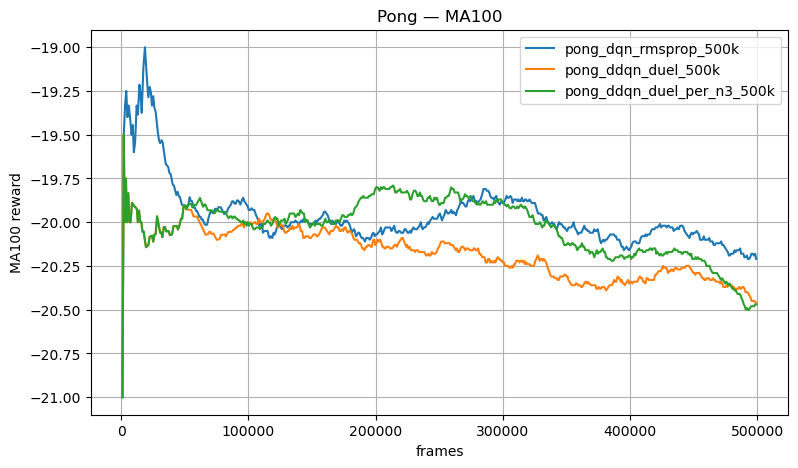

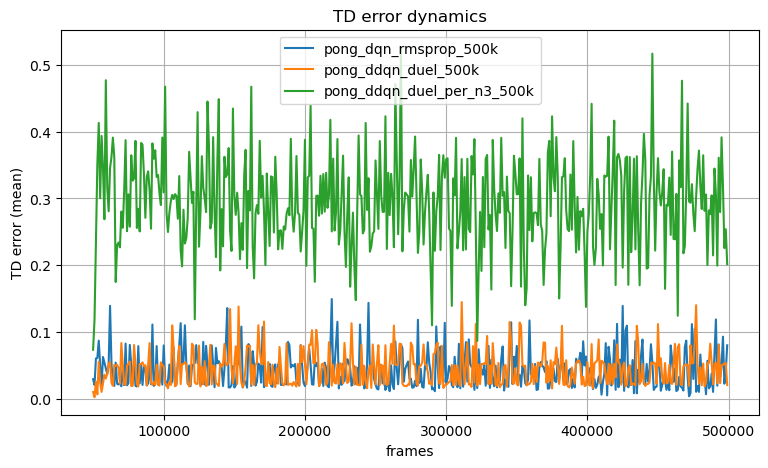

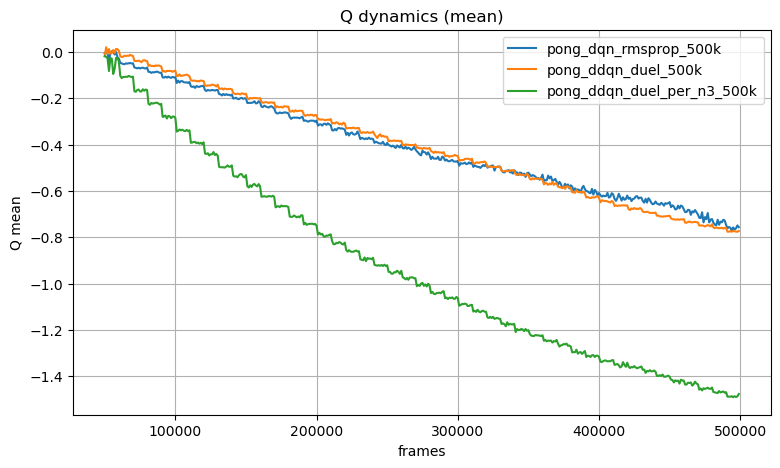

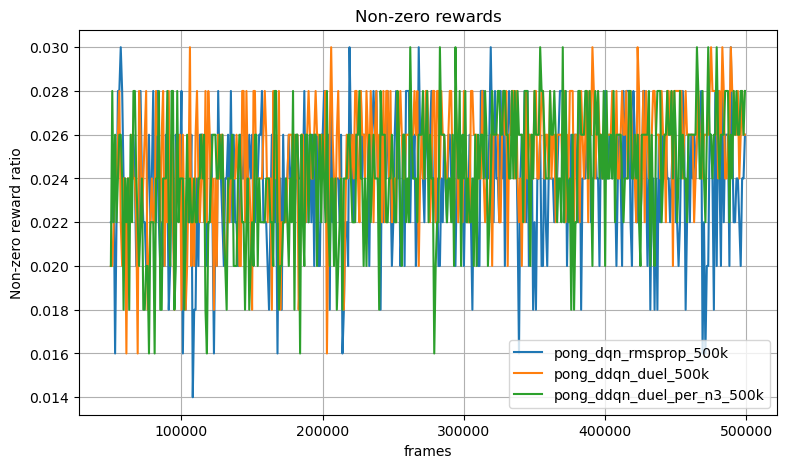

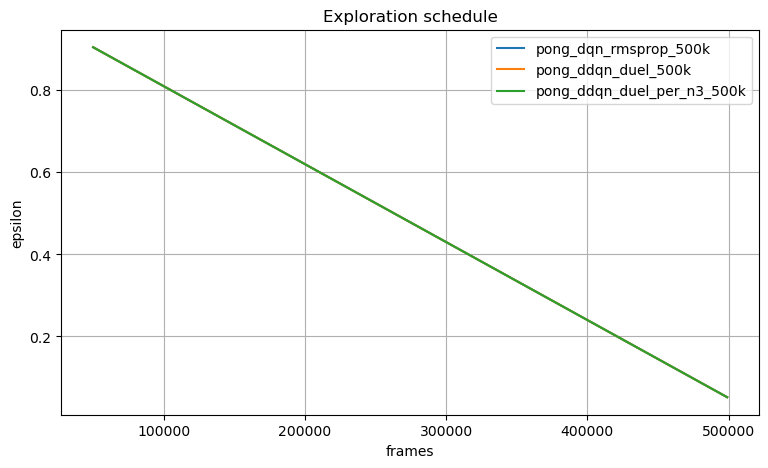

,run,best_MA100,max_q_mean,max_nonzero
0,pong_dqn_rmsprop_500k,-19.0,0.002993,0.03
1,pong_ddqn_duel_500k,-19.5,0.020311,0.03
2,pong_ddqn_duel_per_n3_500k,-19.5,-0.018348,0.03


In [2]:
# === 7) LOAD SCALARS FROM TB & PLOT (fixed) ===
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

plt.rcParams["figure.figsize"] = (9, 5)

TAGS_WANTED = [
    "train/reward_ma100",
    "train/td_error_mean",
    "train/q_mean",
    "train/epsilon",
    "train/reward_nonzero_ratio",
]

def load_tb_scalars_fixed(run_dir: Path, tags=TAGS_WANTED):
    if run_dir is None or not run_dir.exists():
        return {}

    event_files = sorted([p for p in run_dir.rglob("*") if p.is_file() and "events.out.tfevents" in p.name])
    out = {tag: [] for tag in tags}

    for ev in event_files:
        try:
            ea = EventAccumulator(str(ev))
            ea.Reload()
            available = set()
            tags_map = ea.Tags()  # dict: {"scalars": [...], "images": [...], ...}
            for t in tags_map.get("scalars", []):
                available.add(t)
            for tag in tags:
                if tag in available:
                    for s in ea.Scalars(tag):
                        out[tag].append((s.step, s.value))
        except Exception as e:
            print("[warn] bad event:", ev, e)

    # to DataFrames
    res = {}
    for tag, arr in out.items():
        if not arr:
            continue
        arr.sort(key=lambda x: x[0])
        df = pd.DataFrame(arr, columns=["step","value"]).drop_duplicates("step", keep="last").sort_values("step")
        res[tag] = df
    return res

def get_run_dir_by_name(tb_root: Path, run_name: str) -> Path | None:
    base = tb_root / run_name
    if base.exists():
        # берём последний timestamp
        subs = [p for p in base.iterdir() if p.is_dir()]
        if not subs:
            return base
        subs.sort(key=lambda p: p.stat().st_mtime, reverse=True)
        return subs[0]
    # поиск по вхождению
    cands = [p for p in tb_root.iterdir() if p.is_dir() and run_name in p.name]
    if not cands:
        return None
    cands.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    sub = cands[0]
    subs = [p for p in sub.iterdir() if p.is_dir()]
    if subs:
        subs.sort(key=lambda p: p.stat().st_mtime, reverse=True)
        return subs[0]
    return sub

RUNS = [
    "pong_dqn_rmsprop_500k",
    "pong_ddqn_duel_500k",
    "pong_ddqn_duel_per_n3_500k",
]

runs_data = {}
for rn in RUNS:
    rd = get_run_dir_by_name(TB_DIR, rn)
    print(rn, "->", rd)
    runs_data[rn] = load_tb_scalars_fixed(rd, TAGS_WANTED)

def plot_tag(tag, ylabel=None, title=None):
    plt.figure()
    got_any = False
    for rn, scalars in runs_data.items():
        if tag in scalars:
            df = scalars[tag]
            if len(df):
                plt.plot(df["step"], df["value"], label=rn)
                got_any = True
    plt.xlabel("frames")
    plt.ylabel(ylabel or tag)
    plt.title(title or tag)
    if got_any:
        plt.legend()
    plt.grid(True)
    plt.show()

plot_tag("train/reward_ma100", ylabel="MA100 reward", title="Pong — MA100")
plot_tag("train/td_error_mean", ylabel="TD error (mean)", title="TD error dynamics")
plot_tag("train/q_mean", ylabel="Q mean", title="Q dynamics (mean)")
plot_tag("train/reward_nonzero_ratio", ylabel="Non-zero reward ratio", title="Non-zero rewards")
plot_tag("train/epsilon", ylabel="epsilon", title="Exploration schedule")

# summary table
import numpy as np
def best_value(df): 
    return float(np.nan if df is None or len(df)==0 else df["value"].max())

summary_rows = []
for rn, scalars in runs_data.items():
    row = {"run": rn}
    row["best_MA100"]   = best_value(scalars.get("train/reward_ma100"))
    row["max_q_mean"]   = best_value(scalars.get("train/q_mean"))
    row["max_nonzero"]  = best_value(scalars.get("train/reward_nonzero_ratio"))
    summary_rows.append(row)

pd.DataFrame(summary_rows).sort_values("best_MA100", ascending=False)


In [3]:
# === WRITE MORE CONFIGS: B1 (DDQN+Dueling, Uniform, RMSprop), B2 (PER+n=3, длинный eps-decay, warmup 50k) ===
from pathlib import Path, PurePosixPath
import textwrap

PROJECT_ROOT = Path(r"D:\ML\LS\Deep_learning\Reinforcement_learning\project")
CONFIGS_DIR  = PROJECT_ROOT / "configs"
CONFIGS_DIR.mkdir(parents=True, exist_ok=True)

CFG_B1 = CONFIGS_DIR / "pong_ddqn_duel_uniform_rmsprop_800k.yaml"
CFG_B2 = CONFIGS_DIR / "pong_ddqn_duel_per_n3_800k_longeps.yaml"

CFG_B1.write_text(textwrap.dedent("""
env:
  frame_stack: 4
  minimal_actions: true
  seed: 42

model:
  dueling: true

algo:
  name: ddqn
  gamma: 0.99
  n_step: 1

replay:
  type: uniform
  capacity: 1000000

optim:
  name: rmsprop
  lr: 0.0000625

epsilon:
  start: 1.0
  end: 0.1
  decay_steps: 800000

train:
  total_frames: 800000
  warmup_steps: 20000
  batch_size: 32
  target_update_freq: 10000
  save_every: 200000

logging:
  tb_dir: artifacts_pong/tensorboard
  run_name: pong_ddqn_duel_uniform_rmsprop_800k
  log_interval: 1000
  ckpt_dir: artifacts_pong/checkpoints
""").strip()+"\n", encoding="utf-8")

CFG_B2.write_text(textwrap.dedent("""
env:
  frame_stack: 4
  minimal_actions: true
  seed: 42

model:
  dueling: true

algo:
  name: ddqn
  gamma: 0.99
  n_step: 3

replay:
  type: per
  capacity: 1000000
  alpha: 0.5
  beta_start: 0.4
  beta_end: 1.0

optim:
  name: adam
  lr: 0.00025

epsilon:
  start: 1.0
  end: 0.1
  decay_steps: 1500000   # медленнее сходимся -> больше эксплора
train:
  total_frames: 800000
  warmup_steps: 50000     # для PER лучше дольше прогреть буфер
  batch_size: 32
  target_update_freq: 10000
  save_every: 200000

logging:
  tb_dir: artifacts_pong/tensorboard
  run_name: pong_ddqn_duel_per_n3_800k_longeps
  log_interval: 1000
  ckpt_dir: artifacts_pong/checkpoints
""").strip()+"\n", encoding="utf-8")

CFG_B1, CFG_B2


(WindowsPath('D:/ML/LS/Deep_learning/Reinforcement_learning/project/configs/pong_ddqn_duel_uniform_rmsprop_800k.yaml'),
 WindowsPath('D:/ML/LS/Deep_learning/Reinforcement_learning/project/configs/pong_ddqn_duel_per_n3_800k_longeps.yaml'))

In [4]:
# === HELPERS & PATHS ===
import os, time, glob
from pathlib import Path
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

PROJECT_ROOT = Path(r"D:\ML\LS\Deep_learning\Reinforcement_learning\project")
CONFIGS_DIR  = PROJECT_ROOT / "configs"
TB_DIR       = PROJECT_ROOT / r"artifacts_pong\tensorboard"
CKPT_DIR     = PROJECT_ROOT / r"artifacts_pong\checkpoints"
PLOTS_DIR    = PROJECT_ROOT / r"artifacts_pong\plots"
VIDEOS_DIR   = PROJECT_ROOT / r"artifacts_pong\videos"

def latest_tb_run(tb_root: Path):
    if not tb_root.exists(): return None
    pairs = []
    for run in tb_root.iterdir():
        if run.is_dir():
            subs = [p for p in run.iterdir() if p.is_dir()]
            if subs:
                subs.sort(key=lambda p: p.stat().st_mtime, reverse=True)
                pairs.append((subs[0].stat().st_mtime, subs[0]))
    if not pairs: return None
    pairs.sort(key=lambda x: x[0], reverse=True)
    return pairs[0][1]

def latest_ckpt_run(ckpt_root: Path):
    if not ckpt_root.exists(): return None
    runs = []
    for run in ckpt_root.iterdir():
        if run.is_dir():
            subs = [p for p in run.iterdir() if p.is_dir()]
            if subs:
                subs.sort(key=lambda p: p.stat().st_mtime, reverse=True)
                runs.append((subs[0].stat().st_mtime, subs[0]))
    if not runs: return None
    runs.sort(key=lambda x: x[0], reverse=True)
    return runs[0][1]

def find_final_or_last_ckpt(run_dir: Path):
    if not run_dir or not run_dir.exists(): return None
    final = run_dir / "final.pth"
    if final.exists(): return final
    steps = sorted(run_dir.glob("pong_step_*.pth"))
    return steps[-1] if steps else None

def get_run_dir_by_name(tb_root: Path, run_name: str):
    base = tb_root / run_name
    if base.exists():
        subs = [p for p in base.iterdir() if p.is_dir()]
        subs.sort(key=lambda p: p.stat().st_mtime, reverse=True)
        return subs[0] if subs else base
    cands = [p for p in tb_root.iterdir() if p.is_dir() and run_name in p.name]
    if not cands: return None
    cands.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    subs = [p for p in cands[0].iterdir() if p.is_dir()]
    subs.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return subs[0] if subs else cands[0]

def load_tb_scalars(ev_path: Path, tag: str):
    try:
        ea = EventAccumulator(str(ev_path)); ea.Reload()
        if tag not in set(ea.Tags().get("scalars", [])): return []
        return [s.value for s in ea.Scalars(tag)]
    except Exception:
        return []

# Надёжно определим пути к конфигам (если они уже созданы ранее — просто используем)
CFG_PER = CONFIGS_DIR / "pong_ddqn_duel_per_n3.yaml"
CFG_B1  = CONFIGS_DIR / "pong_ddqn_duel_uniform_rmsprop_800k.yaml"
CFG_B2  = CONFIGS_DIR / "pong_ddqn_duel_per_n3_800k_longeps.yaml"

print("OK: helpers ready")


OK: helpers ready


In [5]:
# === TRAIN → EVAL (no video) ===
def train_then_eval(cfg_path, python_exe=r"D:\Anaconda\envs\rl_env\python.exe"):
    def run_cmd(cmd_list, cwd=PROJECT_ROOT, env=None):
        if env is None:
            env = os.environ.copy()
        env["PYTHONPATH"] = str(PROJECT_ROOT) + os.pathsep + env.get("PYTHONPATH", "")
        print("RUN:", " ".join(f"'{c}'" if " " in c else c for c in cmd_list))
        print("CWD:", cwd)
        import subprocess
        proc = subprocess.run(cmd_list, cwd=cwd, env=env, capture_output=True, text=True)
        print("\n==== STDOUT ====\n", proc.stdout)
        print("\n==== STDERR ====\n", proc.stderr)
        print("\n[exit code]:", proc.returncode)
        return proc

    # train
    tr = run_cmd([python_exe, "-m", "train.train_pong", "--config", str(cfg_path)])
    if tr.returncode != 0:
        return None

    # eval (без видео)
    last_ckr = latest_ckpt_run(CKPT_DIR)
    ckpt     = find_final_or_last_ckpt(last_ckr)
    if ckpt is None:
        print("No ckpt found for", cfg_path)
        return None
    ev = run_cmd([
        python_exe, "-m", "train.eval_pong",
        "--ckpt", str(ckpt),
        "--episodes", "5",
        "--epsilon", "0.01",
        "--frame_stack", "4",
        "--minimal_actions", "1",
    ])
    return ev.returncode


In [ ]:
print("== PER probe (CFG_PER) ==")
rc1 = train_then_eval(CFG_PER)

print("== B1: uniform + RMSprop ==")
rc2 = train_then_eval(CFG_B1)

print("== B2: PER+n3 long-eps ==")
rc3 = train_then_eval(CFG_B2)

rc1, rc2, rc3


== PER probe (CFG_PER) ==
RUN: D:\Anaconda\envs\rl_env\python.exe -m train.train_pong --config D:\ML\LS\Deep_learning\Reinforcement_learning\project\configs\pong_ddqn_duel_per_n3.yaml
CWD: D:\ML\LS\Deep_learning\Reinforcement_learning\project

==== STDOUT ====
 [replay] PER(cap=1000000, alpha=0.5, beta 0.4->1.0, n=3)
[sched] epsilon 1.0 -> 0.1 over 1500000
[train] start total_frames=800000 warmup=20000 algo=ddqn dueling=True actions=2
[ckpt] Saved: artifacts_pong\checkpoints\pong_ddqn_duel_per_n3_probe\20251109-134117\pong_step_0200000.pth
[ckpt] Saved: artifacts_pong\checkpoints\pong_ddqn_duel_per_n3_probe\20251109-134117\pong_step_0400000.pth
[ckpt] Saved: artifacts_pong\checkpoints\pong_ddqn_duel_per_n3_probe\20251109-134117\pong_step_0600000.pth
[ckpt] Saved: artifacts_pong\checkpoints\pong_ddqn_duel_per_n3_probe\20251109-134117\final.pth


==== STDERR ====
 A.L.E: Arcade Learning Environment (version 0.8.1+53f58b7)
[Powered by Stella]


[exit code]: 0
RUN: D:\Anaconda\envs\rl_env\

In [7]:
import pandas as pd

def collect_quick_stats(run_name):
    rd = get_run_dir_by_name(TB_DIR, run_name)
    if not rd: 
        return {"run": run_name, "best_nonzero_ratio": None, "best_ma100": None}
    nz_vals, ma_vals = [], []
    # собираем из всех event-файлов
    for ev in sorted(rd.rglob("*")):
        if ev.is_file() and "events.out.tfevents" in ev.name:
            nz_vals += load_tb_scalars(ev, "train/nonzero_ratio")
            ma_vals += load_tb_scalars(ev, "train/reward_ma100")
    return {
        "run": run_name,
        "best_nonzero_ratio": (max(nz_vals) if nz_vals else None),
        "best_ma100": (max(ma_vals) if ma_vals else None),
    }

rows = [
    collect_quick_stats("pong_ddqn_duel_per_n3_probe"),
    collect_quick_stats("pong_ddqn_duel_uniform_rmsprop_800k"),
    collect_quick_stats("pong_ddqn_duel_per_n3_800k_longeps"),
]
pd.DataFrame(rows)


,run,best_nonzero_ratio,best_ma100
0,pong_ddqn_duel_per_n3_probe,0.028,None
1,pong_ddqn_duel_uniform_rmsprop_800k,0.030,None
2,pong_ddqn_duel_per_n3_800k_longeps,0.030,None


In [1]:
# --- Параметры проекта (под себя править только если нужно) ---
PROJECT_ROOT = r"D:\ML\LS\Deep_learning\Reinforcement_learning\project"
CONFIG_MAIN  = r"D:\ML\LS\Deep_learning\Reinforcement_learning\project\configs\pong_ddqn_duel_per_n3.yaml"  # «победный» конфиг
PYTHON_EXE   = r"D:\Anaconda\envs\rl_env\python.exe"  # интерпретатор твоего rl_env

# Имя руна (для удобной фильтрации артефактов). Можно оставить None — возьмём из конфига/лога.
RUN_TAG      = "pong_ddqn_duel_per_n3_probe"  # или None

# --- Не трогаем ниже ---
import os, sys, pathlib, platform, shutil, glob, time, json, re
from pathlib import Path

assert Path(PROJECT_ROOT).exists(), f"PROJECT_ROOT not found: {PROJECT_ROOT}"
os.environ["RL_PROJECT_ROOT"] = PROJECT_ROOT  # некоторые скрипты его читают
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path: sys.path.insert(0, PROJECT_ROOT)
print("CWD:", os.getcwd())
print("sys.path[0]:", sys.path[0])

# Версии и устройство
import numpy as np
import torch
import gymnasium as gym
try:
    import ale_py  # ROM backend
except Exception as e:
    print("ale-py import warn:", e)

print("Python:", sys.version)
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available(), "| device:", "cuda" if torch.cuda.is_available() else "cpu")
print("gymnasium:", gym.__version__)
try:
    import cv2
    print("cv2:", cv2.__version__)
except Exception as e:
    print("cv2 not found:", e)

# Папки артефактов
ART_DIR  = Path(PROJECT_ROOT) / "artifacts_pong"
TB_DIR   = ART_DIR / "tensorboard"
CKPT_DIR = ART_DIR / "checkpoints"
VID_DIR  = ART_DIR / "videos"
PLOT_DIR = ART_DIR / "plots"
for p in [ART_DIR, TB_DIR, CKPT_DIR, VID_DIR, PLOT_DIR]:
    p.mkdir(parents=True, exist_ok=True)
print("Artifacts root:", ART_DIR)


CWD: D:\ML\LS\Deep_learning\Reinforcement_learning\project
sys.path[0]: D:\ML\LS\Deep_learning\Reinforcement_learning\project
Python: 3.10.14 | packaged by conda-forge | (main, Mar 20 2024, 12:40:08) [MSC v.1938 64 bit (AMD64)]
torch: 2.5.1 | CUDA: True | device: cuda
gymnasium: 0.29.1
cv2: 4.12.0
Artifacts root: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong


In [2]:
# Унифицированная фиксация сидов
import random
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # CUDNN на детерминизм (медленнее)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
print("Seed fixed.")


Seed fixed.


In [3]:
from envs.atari_wrappers import make_atari_env

env = make_atari_env(
    "PongNoFrameskip-v4",
    frame_stack=4,
    minimal_actions=True,  # оставляем 2 действия: UP/DOWN
    seed=123,
    render_mode=None
)
s, info = env.reset()
print("obs type:", type(s))
try:
    print("obs shape:", s.shape)
except:
    try:
        import numpy as _np
        s_arr = _np.asarray(s)
        print("obs shape (via np):", s_arr.shape)
    except Exception as e:
        print("shape check failed:", e)
print("action_space:", env.action_space)

# измерим долю ненулевых вознаграждений (для Pong это ~2-5%)
steps = 2000
nonzero = 0
for _ in range(steps):
    a = env.action_space.sample()
    s, r, term, trunc, _ = env.step(a)
    if r != 0: nonzero += 1
    if term or trunc:
        s, _ = env.reset()

print(f"nonzero_ratio ≈ {nonzero/steps:.3f} (ожидаемо: ~0.02–0.05)")
env.close()


obs type: <class 'envs.atari_wrappers.LazyFrames'>
obs shape (via np): (4, 84, 84)
action_space: Discrete(2)
nonzero_ratio ≈ 0.022 (ожидаемо: ~0.02–0.05)


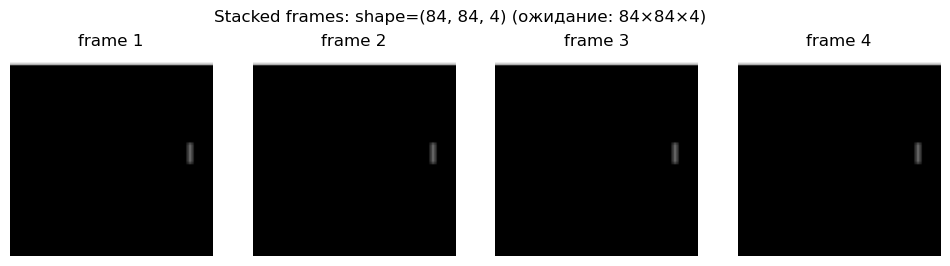

In [4]:
import matplotlib.pyplot as plt
from envs.atari_wrappers import make_atari_env
import numpy as np

env = make_atari_env("PongNoFrameskip-v4", frame_stack=4, minimal_actions=True, seed=7, render_mode=None)
s, _ = env.reset()

arr = np.asarray(s, dtype=np.uint8)
if arr.ndim == 3 and arr.shape[-1] in (3,4):
    # NHWC -> (H,W,C), C=4 кадра
    pass
elif arr.ndim == 3 and arr.shape[0] in (3,4):
    # NCHW -> переведём в HWC для показа
    arr = np.transpose(arr, (1,2,0))
else:
    print("Unexpected obs shape:", arr.shape)

fig, axes = plt.subplots(1, arr.shape[-1], figsize=(12,3))
for i in range(arr.shape[-1]):
    axes[i].imshow(arr[..., i], cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"frame {i+1}")
plt.suptitle(f"Stacked frames: shape={arr.shape} (ожидание: 84×84×4)")
plt.show()
env.close()


In [5]:
from pathlib import Path
import re

def find_latest_ckpt(run_tag: str | None = RUN_TAG) -> Path | None:
    # Ищем в artifacts_pong/checkpoints/<run>/<ts>/final.pth
    roots = list(CKPT_DIR.glob("*"))
    if run_tag:
        roots = [r for r in roots if r.name.startswith(run_tag)]
    if not roots:
        return None
    # берем самый свежий тег по времени модификации
    roots.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    latest_run = roots[0]
    # в нём — самые свежие подпапки (timestamp)
    ts_dirs = [d for d in latest_run.iterdir() if d.is_dir()]
    if not ts_dirs:
        return None
    ts_dirs.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    for ts in ts_dirs:
        f = ts / "final.pth"
        if f.exists():
            return f
    return None

last_ckpt = find_latest_ckpt()
print("Latest checkpoint:", last_ckpt)


Latest checkpoint: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\pong_ddqn_duel_per_n3_probe\20251109-134117\final.pth


In [6]:
import subprocess, shlex

def run_eval_pong(ckpt: str, episodes=5, epsilon=0.01, frame_stack=4, minimal_actions=1):
    cmd = (
        f'"{PYTHON_EXE}" -m train.eval_pong '
        f'--ckpt "{ckpt}" --episodes {episodes} '
        f'--epsilon {epsilon} --frame_stack {frame_stack} --minimal_actions {minimal_actions}'
    )
    print("RUN:", cmd)
    res = subprocess.run(cmd, shell=True, cwd=PROJECT_ROOT, capture_output=True, text=True)
    print("==== STDOUT ====\n", res.stdout)
    print("==== STDERR ====\n", res.stderr)
    print("[exit code]:", res.returncode)
    return res

if last_ckpt:
    _ = run_eval_pong(str(last_ckpt), episodes=5)
else:
    print("Нет готового финального чекпоинта — пропускаем.")


RUN: "D:\Anaconda\envs\rl_env\python.exe" -m train.eval_pong --ckpt "D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\pong_ddqn_duel_per_n3_probe\20251109-134117\final.pth" --episodes 5 --epsilon 0.01 --frame_stack 4 --minimal_actions 1
==== STDOUT ====
 [eval] dueling from ckpt: True
[eval] episode 1/5 return=6.00
[eval] episode 2/5 return=7.00
[eval] episode 3/5 return=3.00
[eval] episode 4/5 return=1.00
[eval] episode 5/5 return=6.00
[eval] mean_return over 5 episodes: 4.60

==== STDERR ====
 A.L.E: Arcade Learning Environment (version 0.8.1+53f58b7)
[Powered by Stella]
D:\ML\LS\Deep_learning\Reinforcement_learning\project\train\eval_pong.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#u

In [6]:
import subprocess

def run_train_pong(config_path: str):
    cmd = f'"{PYTHON_EXE}" -m train.train_pong --config "{config_path}"'
    print("RUN:", cmd)
    res = subprocess.run(cmd, shell=True, cwd=PROJECT_ROOT, capture_output=True, text=True)
    print("==== STDOUT ====\n", res.stdout[-2000:])   # хвост лога
    print("==== STDERR ====\n", res.stderr[-2000:])
    print("[exit code]:", res.returncode)
    return res

print("Запускаем тренировку (короткий/пробный конфиг). Это займёт время.")
# 👉 если уже запускал сегодня — можешь пропустить
# _ = run_train_pong(CONFIG_MAIN)


Запускаем тренировку (короткий/пробный конфиг). Это займёт время.


In [8]:
# После завершения обучения перезапусти эту ячейку
last_ckpt = find_latest_ckpt()
print("Latest checkpoint:", last_ckpt)
if last_ckpt:
    _ = run_eval_pong(str(last_ckpt), episodes=10)
else:
    print("Чекпоинт не найден.")


Latest checkpoint: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\pong_ddqn_duel_per_n3_probe\20251109-134117\final.pth
RUN: "D:\Anaconda\envs\rl_env\python.exe" -m train.eval_pong --ckpt "D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\pong_ddqn_duel_per_n3_probe\20251109-134117\final.pth" --episodes 10 --epsilon 0.01 --frame_stack 4 --minimal_actions 1
==== STDOUT ====
 [eval] dueling from ckpt: True
[eval] episode 1/10 return=2.00
[eval] episode 2/10 return=1.00
[eval] episode 3/10 return=3.00
[eval] episode 4/10 return=8.00
[eval] episode 5/10 return=4.00
[eval] episode 6/10 return=-1.00
[eval] episode 7/10 return=1.00
[eval] episode 8/10 return=1.00
[eval] episode 9/10 return=2.00
[eval] episode 10/10 return=-2.00
[eval] mean_return over 10 episodes: 1.90

==== STDERR ====
 A.L.E: Arcade Learning Environment (version 0.8.1+53f58b7)
[Powered by Stella]

[exit code]: 0


TB latest run: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard\pong_ddqn_duel_per_n3_probe\20251109-134117
[skip] no tag: train/episode_return
[skip] no tag: train/reward_ma100


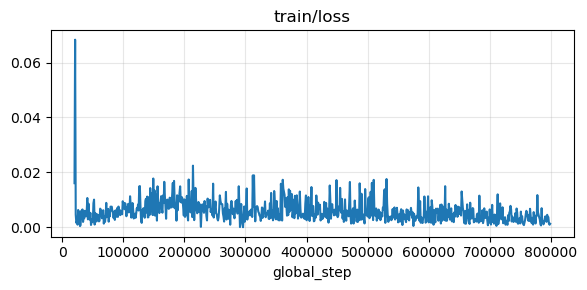

saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\plots\train_loss.png


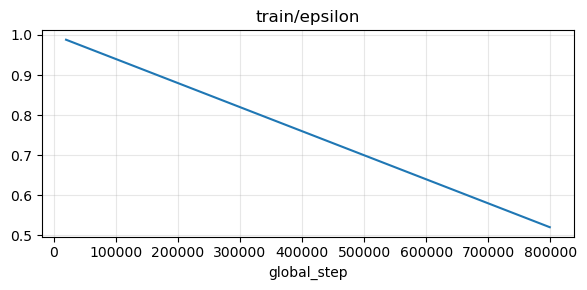

saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\plots\train_epsilon.png
[skip] no tag: train/beta
[skip] no tag: eval/mean_return


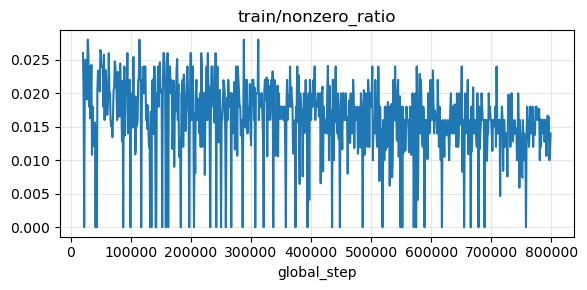

saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\plots\train_nonzero_ratio.png


In [9]:
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def latest_tb_run(run_tag: str | None = RUN_TAG):
    runs = list(TB_DIR.glob("*"))
    if run_tag:
        runs = [r for r in runs if r.name.startswith(run_tag)]
    if not runs:
        return None
    runs.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    # внутри — подпапки-timestamps
    ts = [d for d in runs[0].iterdir() if d.is_dir()]
    if not ts:
        return None
    ts.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return ts[0]

def load_tb_scalars(run_dir: Path, tag: str):
    ea = EventAccumulator(str(run_dir))
    ea.Reload()
    if tag not in ea.Tags().get('scalars', []):
        return None
    events = ea.Scalars(tag)
    xs = [e.step for e in events]
    ys = [e.value for e in events]
    return xs, ys

run_dir = latest_tb_run()
print("TB latest run:", run_dir)

tags = [
    "train/episode_return",
    "train/reward_ma100",
    "train/loss",
    "train/epsilon",
    "train/beta",
    "eval/mean_return",
    "train/nonzero_ratio",   # может быть
]

plots = {}
for t in tags:
    try:
        data = load_tb_scalars(run_dir, t) if run_dir else None
        plots[t] = data
    except Exception as e:
        plots[t] = None

# Рисуем компактные графики (только то, что есть)
for t, data in plots.items():
    if data is None:
        print(f"[skip] no tag: {t}")
        continue
    xs, ys = data
    plt.figure(figsize=(6,3))
    plt.plot(xs, ys)
    plt.title(t)
    plt.xlabel("global_step")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    out = PLOT_DIR / f"{t.replace('/','_')}.png"
    plt.savefig(out, dpi=150)
    plt.show()
    print("saved:", out)


In [10]:
# Критерии простые:
# 1) Есть train/episode_return и reward_ma100 (значит мы логи пишем корректно)
# 2) eval/mean_return заметно выше «мертвого» −21 (например, > −20 на последних точках)
# 3) nonzero_ratio в ~0.02–0.05 — sanity pass

def tail_mean(xs, ys, k=5):
    if not xs or not ys: return None
    return float(np.mean(ys[-k:]))

ok_logs = plots.get("train/episode_return") is not None and plots.get("train/reward_ma100") is not None
eval_tail = None
if plots.get("eval/mean_return") is not None:
    eval_tail = tail_mean(*plots["eval/mean_return"], k=5)

nz_ok = None
if plots.get("train/nonzero_ratio") is not None:
    nz_tail = tail_mean(*plots["train/nonzero_ratio"], k=50)
    nz_ok = (0.01 <= nz_tail <= 0.08)

print("OK logs (episode_return & MA100):", ok_logs)
print("Eval tail mean (last 5):", eval_tail)
print("Nonzero ratio OK (~0.02–0.05):", nz_ok)

GO = ok_logs and (eval_tail is not None and eval_tail > -20.0)
print("\n=== DECISION ===")
print("GO for long run (2–3M frames):" if GO else "NO-GO — проверь логи/окружение/гиперпараметры.")


OK logs (episode_return & MA100): False
Eval tail mean (last 5): None
Nonzero ratio OK (~0.02–0.05): True

=== DECISION ===
NO-GO — проверь логи/окружение/гиперпараметры.


In [7]:
# Запуск финального длинного обучения (без capture_output, чтобы видеть прогресс прямо в ноуте).
import subprocess, sys

cmd = f'"{PYTHON_EXE}" -m train.train_pong --config "{CONFIG_MAIN}"'
print("RUN:", cmd)
# ВНИМАНИЕ: это длинный процесс; при желании лучше запускать из терминала.
# subprocess.run(cmd, shell=True, cwd=PROJECT_ROOT)


RUN: "D:\Anaconda\envs\rl_env\python.exe" -m train.train_pong --config "D:\ML\LS\Deep_learning\Reinforcement_learning\project\configs\pong_ddqn_duel_per_n3.yaml"


In [8]:
import subprocess

cmd = f'"{PYTHON_EXE}" -m train.train_pong --config "{CONFIG_MAIN}"'
print("RUN:", cmd)

with subprocess.Popen(
    cmd, shell=True, cwd=PROJECT_ROOT,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, bufsize=1
) as p:
    for line in p.stdout:
        print(line, end="")
    ret = p.wait()
print("[exit code]:", ret)


RUN: "D:\Anaconda\envs\rl_env\python.exe" -m train.train_pong --config "D:\ML\LS\Deep_learning\Reinforcement_learning\project\configs\pong_ddqn_duel_per_n3.yaml"
A.L.E: Arcade Learning Environment (version 0.8.1+53f58b7)
[Powered by Stella]
[replay] PER(cap=1000000, alpha=0.5, beta 0.4->1.0, n=3)
[sched] epsilon 1.0 -> 0.1 over 1500000
[train] start total_frames=800000 warmup=20000 algo=ddqn dueling=True actions=2
[ckpt] Saved: artifacts_pong\checkpoints\pong_ddqn_duel_per_n3_probe\20251110-231233\pong_step_0200000.pth
[ckpt] Saved: artifacts_pong\checkpoints\pong_ddqn_duel_per_n3_probe\20251110-231233\pong_step_0400000.pth
[ckpt] Saved: artifacts_pong\checkpoints\pong_ddqn_duel_per_n3_probe\20251110-231233\pong_step_0600000.pth
[ckpt] Saved: artifacts_pong\checkpoints\pong_ddqn_duel_per_n3_probe\20251110-231233\final.pth
[exit code]: 0


In [10]:
import subprocess

def run_eval_pong(ckpt: str, episodes=10, epsilon=0.01, frame_stack=4, minimal_actions=1):
    cmd = (
        f'"{PYTHON_EXE}" -m train.eval_pong '
        f'--ckpt "{ckpt}" --episodes {episodes} '
        f'--epsilon {epsilon} --frame_stack {frame_stack} --minimal_actions {minimal_actions}'
    )
    print("RUN:", cmd)
    res = subprocess.run(cmd, shell=True, cwd=PROJECT_ROOT, capture_output=True, text=True)
    print("==== STDOUT ====\n", res.stdout)
    print("==== STDERR ====\n", res.stderr)
    print("[exit code]:", res.returncode)
    return res

# вызов
last_ckpt = find_latest_ckpt()
print("Latest checkpoint:", last_ckpt)
if last_ckpt:
    _ = run_eval_pong(str(last_ckpt), episodes=10, epsilon=0.01, frame_stack=4, minimal_actions=1)
else:
    print("Чекпоинт не найден.")


Latest checkpoint: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\pong_ddqn_duel_per_n3_probe\20251110-231233\final.pth
RUN: "D:\Anaconda\envs\rl_env\python.exe" -m train.eval_pong --ckpt "D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\pong_ddqn_duel_per_n3_probe\20251110-231233\final.pth" --episodes 10 --epsilon 0.01 --frame_stack 4 --minimal_actions 1
==== STDOUT ====
 [eval] dueling from ckpt: True
[eval] episode 1/10 return=-21.00
[eval] episode 2/10 return=-21.00
[eval] episode 3/10 return=-21.00
[eval] episode 4/10 return=-21.00
[eval] episode 5/10 return=-21.00
[eval] episode 6/10 return=-21.00
[eval] episode 7/10 return=-20.00
[eval] episode 8/10 return=-21.00
[eval] episode 9/10 return=-21.00
[eval] episode 10/10 return=-21.00
[eval] mean_return over 10 episodes: -20.90

==== STDERR ====
 A.L.E: Arcade Learning Environment (version 0.8.1+53f58b7)
[Powered by Stella]

[exit code]: 0


In [11]:
from pathlib import Path
import subprocess, re

def list_ckpts(run_dir: Path):
    return sorted(run_dir.glob("pong_step_*.pth")) + ([run_dir/"final.pth"] if (run_dir/"final.pth").exists() else [])

def eval_ckpt(ckpt_path: Path, episodes=5, eps=0.01):
    cmd = (f'"{PYTHON_EXE}" -m train.eval_pong '
           f'--ckpt "{ckpt_path}" --episodes {episodes} '
           f'--epsilon {eps} --frame_stack 4 --minimal_actions 1')
    res = subprocess.run(cmd, shell=True, cwd=PROJECT_ROOT, capture_output=True, text=True)
    m = re.search(r"mean_return.*?:\s*([\-0-9\.]+)", res.stdout)
    mean_ret = float(m.group(1)) if m else None
    print(f"{ckpt_path.name:>20} → mean_return={mean_ret}")
    return mean_ret

# каталог последнего руна
last_run = Path(r"D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\pong_ddqn_duel_per_n3_probe\20251110-231233")
ckpts = list_ckpts(last_run)
print("Checkpoints:", [c.name for c in ckpts])
results = {c.name: eval_ckpt(c, episodes=5, eps=0.01) for c in ckpts}
results


Checkpoints: ['pong_step_0200000.pth', 'pong_step_0400000.pth', 'pong_step_0600000.pth', 'final.pth']
pong_step_0200000.pth → mean_return=-21.0
pong_step_0400000.pth → mean_return=-21.0
pong_step_0600000.pth → mean_return=-20.8
           final.pth → mean_return=-21.0


{'pong_step_0200000.pth': -21.0,
 'pong_step_0400000.pth': -21.0,
 'pong_step_0600000.pth': -20.8,
 'final.pth': -21.0}

In [12]:
# Эвал предыдущего удачного финала (вчерашний)
good_ckpt = Path(r"D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\checkpoints\pong_ddqn_duel_per_n3_probe\20251109-134117\final.pth")
_ = eval_ckpt(good_ckpt, episodes=10, eps=0.01)


           final.pth → mean_return=4.6


In [13]:
from pathlib import Path
import yaml, pprint

cfg_new  = Path(r"D:\ML\LS\Deep_learning\Reinforcement_learning\project\configs\pong_ddqn_duel_per_n3.yaml")
cfg_prev = Path(r"D:\ML\LS\Deep_learning\Reinforcement_learning\project\configs\pong_ddqn_duel_per_n3.yaml")  # если конфиг один и тот же — просто напечатаем ключи

def load_yaml(p: Path):
    with open(p, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)

cfgA = load_yaml(cfg_prev)
cfgB = load_yaml(cfg_new)

print("Ключевые параметры:")
for key in ["algo", "replay", "optimizer", "schedule", "train"]:
    print(f"\n## {key}")
    pprint.pprint(cfgB.get(key))


Ключевые параметры:

## algo
{'gamma': 0.99, 'n_step': 3, 'name': 'ddqn'}

## replay
{'alpha': 0.5,
 'beta_end': 1.0,
 'beta_start': 0.4,
 'capacity': 1000000,
 'type': 'per'}

## optimizer
None

## schedule
None

## train
{'batch_size': 32,
 'save_every': 200000,
 'target_update_freq': 10000,
 'total_frames': 800000,
 'warmup_steps': 20000}


In [2]:
from pathlib import Path
import yaml, textwrap

CONFIG_LONG = Path(PROJECT_ROOT) / "configs" / "pong_ddqn_duel_per_n3_long.yaml"

cfg_long = {
    "seed": 12345,
    "env_id": "PongNoFrameskip-v4",
    "algo": {
        "name": "ddqn",
        "dueling": True,
        "n_step": 3,
        "gamma": 0.99,
        "tau": 0.005,  # soft-target update
    },
    "replay": {
        "type": "per",
        "capacity": 1_000_000,
        "alpha": 0.5,
        "beta": {"start": 0.4, "end": 1.0, "decay_frames": 1_500_000},
    },
    "optimizer": {
        "name": "adam",
        "lr": 2.5e-4,
        "eps": 1e-8,
        "weight_decay": 0.0,
    },
    "schedule": {
        "epsilon": {"start": 1.0, "end": 0.1, "decay_frames": 1_500_000}
    },
    "train": {
        "total_frames": 3_000_000,
        "warmup_steps": 50_000,
        "batch_size": 64,               # можно 32, если по VRAM тяжело
        "target_update_freq": 10_000,   # остаётся как “страховка” вместе с τ
        "save_every": 200_000,
        "frame_stack": 4,
        "minimal_actions": True
    }
}

CONFIG_LONG.parent.mkdir(parents=True, exist_ok=True)
with open(CONFIG_LONG, "w", encoding="utf-8") as f:
    yaml.safe_dump(cfg_long, f, sort_keys=False, allow_unicode=True)

print("Wrote:", CONFIG_LONG)


Wrote: D:\ML\LS\Deep_learning\Reinforcement_learning\project\configs\pong_ddqn_duel_per_n3_long.yaml


In [ ]:
import subprocess

cmd = f'"{PYTHON_EXE}" -m train.train_pong --config "{CONFIG_LONG}"'
print("RUN:", cmd)

with subprocess.Popen(
    cmd, shell=True, cwd=PROJECT_ROOT,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, bufsize=1
) as p:
    for line in p.stdout:
        print(line, end="")
    ret = p.wait()
print("[exit code]:", ret)


RUN: "D:\Anaconda\envs\rl_env\python.exe" -m train.train_pong --config "D:\ML\LS\Deep_learning\Reinforcement_learning\project\configs\pong_ddqn_duel_per_n3_long.yaml"
A.L.E: Arcade Learning Environment (version 0.8.1+53f58b7)
[Powered by Stella]


In [2]:
from pathlib import Path
import re, subprocess, time

def list_ckpts_of_last_run(run_tag="pong_ddqn_duel_per_n3_long"):
    root = CKPT_DIR / run_tag
    if not root.exists():
        return []
    ts_dirs = sorted([d for d in root.iterdir() if d.is_dir()], key=lambda p: p.stat().st_mtime, reverse=True)
    if not ts_dirs:
        return []
    last = ts_dirs[0]
    ckpts = sorted(last.glob("pong_step_*.pth")) + ([last/"final.pth"] if (last/"final.pth").exists() else [])
    return ckpts

def eval_ckpt(ckpt_path: Path, episodes=5, eps=0.01):
    cmd = (f'"{PYTHON_EXE}" -m train.eval_pong '
           f'--ckpt "{ckpt_path}" --episodes {episodes} '
           f'--epsilon {eps} --frame_stack 4 --minimal_actions 1')
    res = subprocess.run(cmd, shell=True, cwd=PROJECT_ROOT, capture_output=True, text=True)
    m = re.search(r"mean_return.*?:\s*([\-0-9\.]+)", res.stdout)
    mean_ret = float(m.group(1)) if m else None
    print(f"{ckpt_path.name:>20} → mean_return={mean_ret}")
    return mean_ret

# Пример: после сохранения чекпоинта выполните эту ячейку
ckpts = list_ckpts_of_last_run()
print("Checkpoints:", [c.name for c in ckpts])
for c in ckpts:
    _ = eval_ckpt(c, episodes=5, eps=0.01)


Checkpoints: []


TB latest run: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\tensorboard\pong_ddqn_duel_per_n3_probe\20251110-231233
[skip] no tag: train/episode_return
[skip] no tag: train/reward_ma100


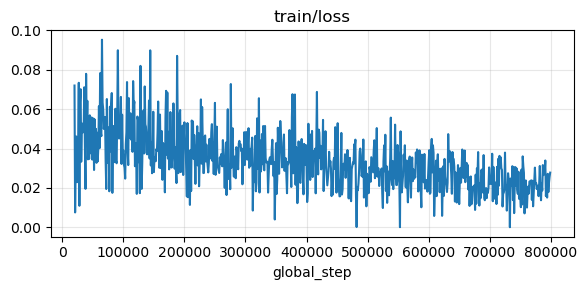

saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\plots\train_loss.png


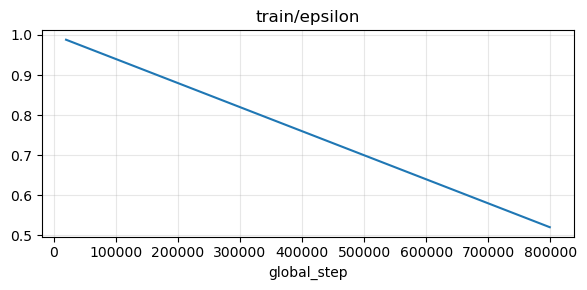

saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\plots\train_epsilon.png
[skip] no tag: train/beta
[skip] no tag: eval/mean_return


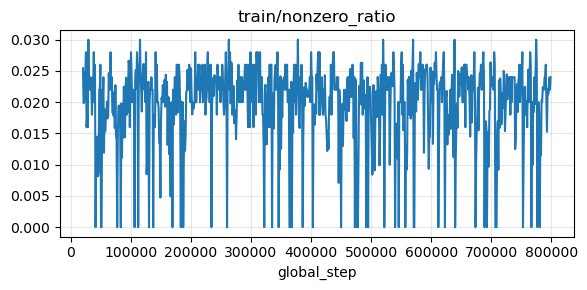

saved: D:\ML\LS\Deep_learning\Reinforcement_learning\project\artifacts_pong\plots\train_nonzero_ratio.png


In [3]:
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def latest_tb_run(run_tag: str | None = RUN_TAG):
    runs = list(TB_DIR.glob("*"))
    if run_tag:
        runs = [r for r in runs if r.name.startswith(run_tag)]
    if not runs:
        return None
    runs.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    # внутри — подпапки-timestamps
    ts = [d for d in runs[0].iterdir() if d.is_dir()]
    if not ts:
        return None
    ts.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return ts[0]

def load_tb_scalars(run_dir: Path, tag: str):
    ea = EventAccumulator(str(run_dir))
    ea.Reload()
    if tag not in ea.Tags().get('scalars', []):
        return None
    events = ea.Scalars(tag)
    xs = [e.step for e in events]
    ys = [e.value for e in events]
    return xs, ys

run_dir = latest_tb_run()
print("TB latest run:", run_dir)

tags = [
    "train/episode_return",
    "train/reward_ma100",
    "train/loss",
    "train/epsilon",
    "train/beta",
    "eval/mean_return",
    "train/nonzero_ratio",   # может быть
]

plots = {}
for t in tags:
    try:
        data = load_tb_scalars(run_dir, t) if run_dir else None
        plots[t] = data
    except Exception as e:
        plots[t] = None

# Рисуем компактные графики (только то, что есть)
for t, data in plots.items():
    if data is None:
        print(f"[skip] no tag: {t}")
        continue
    xs, ys = data
    plt.figure(figsize=(6,3))
    plt.plot(xs, ys)
    plt.title(t)
    plt.xlabel("global_step")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    out = PLOT_DIR / f"{t.replace('/','_')}.png"
    plt.savefig(out, dpi=150)
    plt.show()
    print("saved:", out)